# 10주차_시계열 데이터와 순환 신경망

- 참고자료 : How You Can Earn Money With AI
- Preview
- 시계열 데이터의 이해
- 순환 신경망
- LSTM으로 시계열 예측하기
- 편곡하는 인공지능
- 자연어 처리
- Encoder-Decoder/어텐션 메커니즘/트랜스포머

---

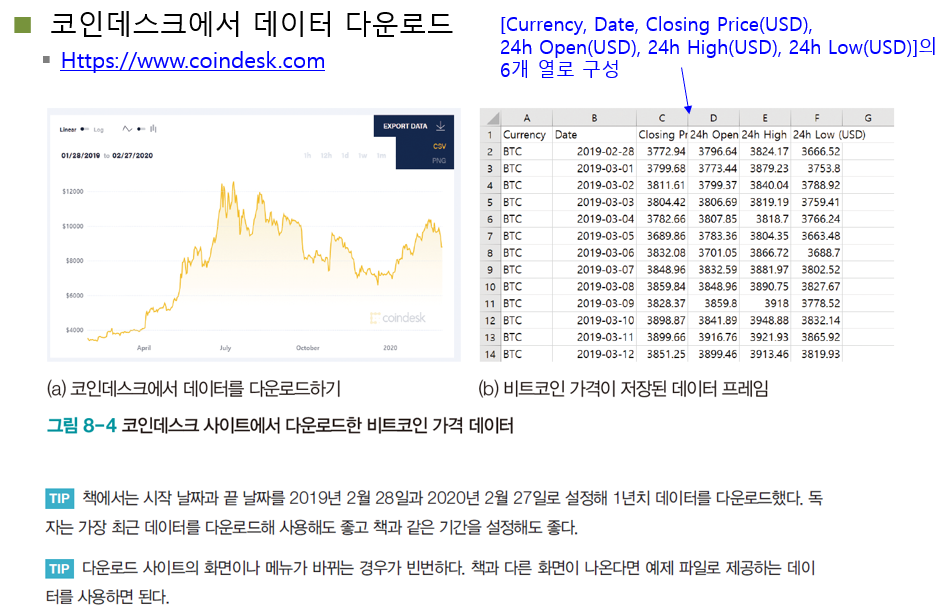

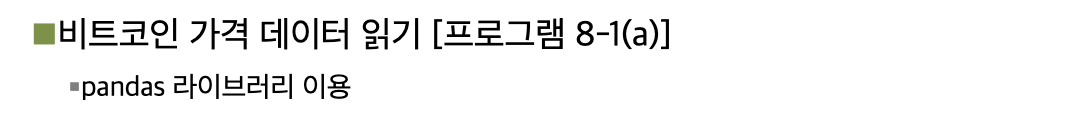
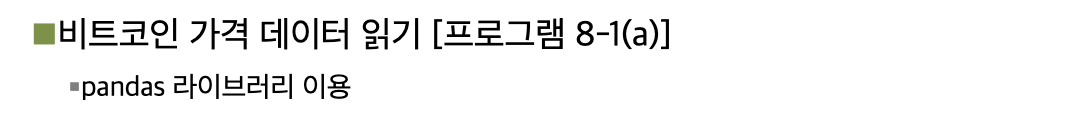

In [ ]:
import numpy as np
# 수치 데이터를 배열로 표현하고 과학 계산을 쉽게 처리하기 위한 NumPy 라이브러리 호출
import pandas as pd
# 표 형태의 데이터를 불러오고 조작할 수 있는 Pandas 라이브러리 호출
import matplotlib.pyplot as plt
# 그래프를 그릴 수 있는 시각화 도구인 matplotlib의 pyplot 모듈 호출

# 코인데스크 사이트에서 다운로드한 1년치 비트코인 가격 데이터 읽기
f = open('BTC_USD_2019-02-28_2020-02-27-CoinDesk.csv', 'r')
# 로컬에 저장된 CSV 파일을 읽기 모드로 열어 파일 객체 생성
coindesk_data = pd.read_csv(f, header=0)
# 파일 객체를 통해 CSV 데이터를 읽어 Pandas의 데이터프레임 형태로 저장하며, 첫 번째 줄을 열 이름으로 사용
seq = coindesk_data[['Closing Price (USD)']].to_numpy()
# 데이터프레임에서 'Closing Price (USD)' 열만 추출한 후, 이를 넘파이 배열로 변환하여 수치 계산에 적합하게 준비
print('데이터 길이:', len(seq), '\n앞쪽 5개 값:', seq[0:5])
# 전체 데이터의 길이와 앞쪽 5개 데이터를 출력하여 데이터 로딩 결과를 확인

# 그래프로 데이터 확인
plt.plot(seq, color='red')
# 비트코인 가격의 시계열 데이터를 빨간색 선 그래프로 시각화
plt.title('Bitcoin Prices (1 year from 2019-02-28)')
# 그래프의 제목을 설정하여 데이터의 시간 범위를 명시
plt.xlabel('Days')
# x축에 'Days'라는 레이블을 붙여 각 데이터가 일 단위임을 표시
plt.ylabel('Price in USD')
# y축에 'Price in USD'라는 레이블을 붙여 가격 단위가 달러임을 표시
plt.show()
# 위에서 설정한 그래프를 화면에 출력


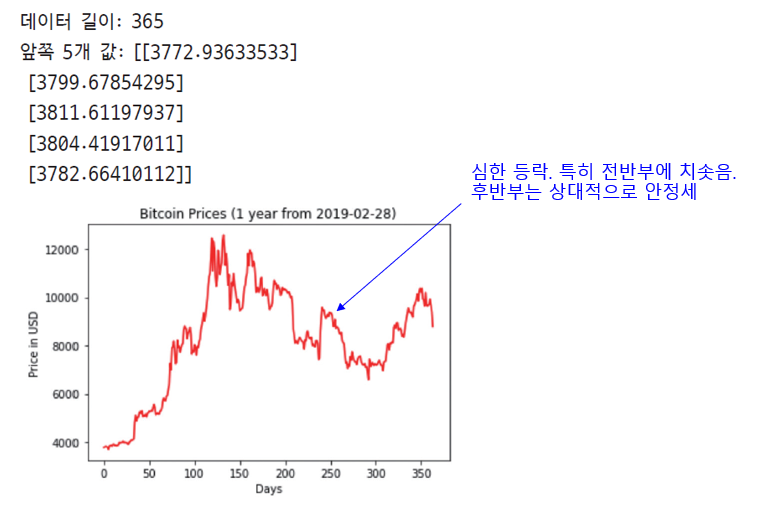

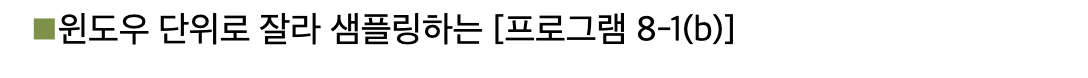

In [ ]:
# 시계열 데이터를 윈도우 단위로 자르는 함수
def seq2dataset(seq, window, horizon):
    # 시계열 데이터(seq)를 입력받아, 주어진 윈도우(window) 크기와 예측 지연(horizon)을 기준으로 학습용 입력(X)과 출력(Y) 데이터를 생성하는 함수 정의
    X = []; Y = []
    # 입력 시퀀스를 저장할 리스트 X와 정답값을 저장할 리스트 Y 초기화
    for i in range(len(seq) - (window + horizon) + 1):
        # 전체 시퀀스 길이에서 윈도우 크기와 예측 지연값을 고려하여 슬라이딩하며 반복 처리
        x = seq[i:(i + window)]
        # 현재 위치 i부터 윈도우 크기만큼 잘라낸 부분을 입력 시퀀스 x로 정의
        y = (seq[i + window + horizon - 1])
        # 윈도우 이후 horizon 만큼 떨어진 시점의 값을 정답값 y로 정의
        X.append(x); Y.append(y)
        # 생성한 x와 y를 각각 리스트 X와 Y에 추가하여 누적
#        print(x)
#        print('y=', y)
    return np.array(X), np.array(Y)
    # 리스트 형태로 저장된 X와 Y를 넘파이 배열로 변환하여 반환

w = 7
# 입력 시퀀스를 몇 개의 일 단위로 자를 것인지 정하는 윈도우 크기를 7일로 설정
h = 1
# 정답값이 윈도우 이후 며칠 뒤의 값을 예측할 것인지 지정하는 수평선 계수를 1일로 설정
X, Y = seq2dataset(seq, w, h)
# 앞서 정의한 seq2dataset 함수를 호출하여 시퀀스 데이터를 윈도우 단위로 자르고 예측용 타깃 데이터를 생성
print(X.shape, Y.shape)
# 입력 배열 X와 출력 배열 Y의 차원 정보를 출력하여 데이터 구조를 확인
print(X[0], Y[0])
# 첫 번째 입력 시퀀스와 해당 시퀀스에 대한 정답값을 출력하여 예시 확인
print(X[-1], Y[-1])
# 마지막 입력 시퀀스와 해당 시퀀스에 대한 정답값을 출력하여 경계값 처리 결과 확인

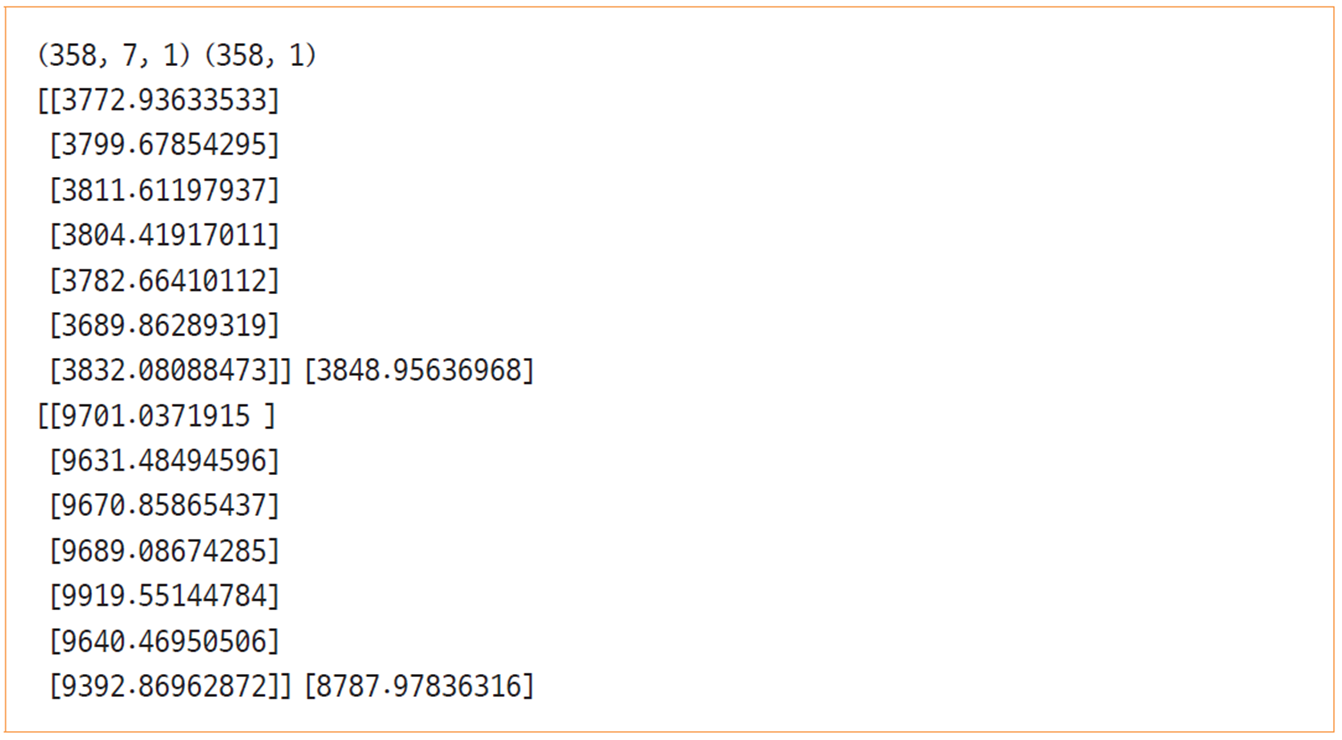

---

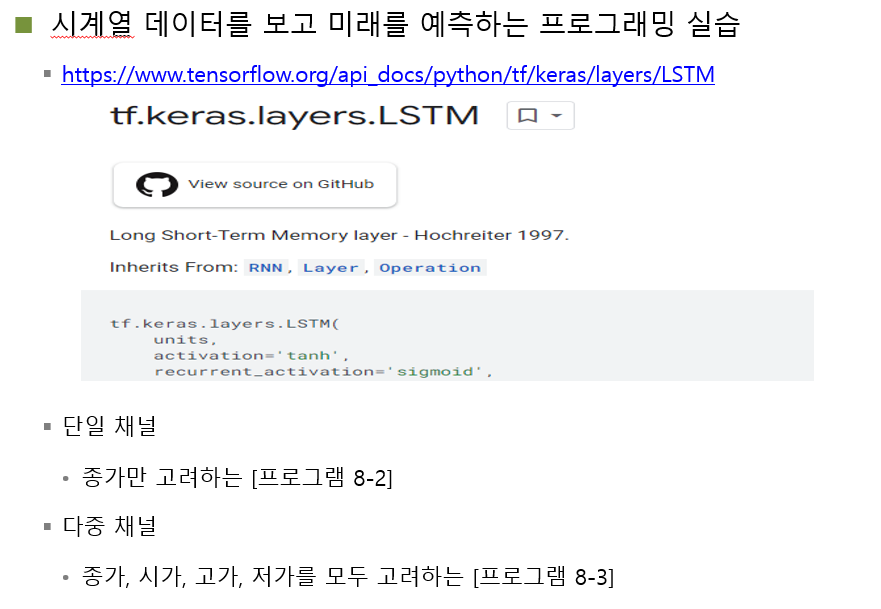

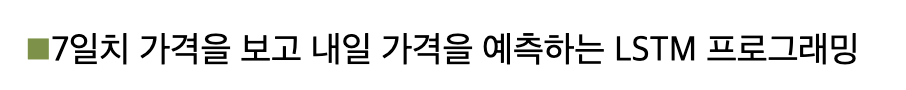

In [ ]:
# ------------------------------------------------------------
# [전체 개요: Overview]
# 본 코드는 코인데스크에서 수집한 비트코인 가격 데이터를 활용하여,
# 시계열 데이터를 LSTM(Long Short-Term Memory) 모델의 입력으로 변환하고,
# 미래 비트코인 가격을 예측하는 과정을 포함한 시계열 예측 모델 학습 예제임.
# 데이터 로딩, 전처리, 윈도우화, 모델 설계 및 학습, 평가, 시각화를 모두 포함함.
# ------------------------------------------------------------

# ------------------------------------------------------------
# [처리 흐름: Step-by-step Flow]
# 1단계: 필요한 라이브러리 불러오기
# 2단계: 비트코인 CSV 데이터 읽기 및 시계열 데이터 추출
# 3단계: 시계열 데이터를 LSTM 입력 형식으로 윈도우 단위로 변환
# 4단계: 훈련/테스트 데이터 분할
# 5단계: LSTM 모델 설계, 컴파일, 학습
# 6단계: 모델 평가 및 예측
# 7단계: 학습 곡선 및 예측 결과 시각화
# ------------------------------------------------------------

# ==============================
# 1단계: 필요한 라이브러리 불러오기
# ==============================

import numpy as np
# 배열 기반 수치 연산을 위한 NumPy 라이브러리 불러오기

import pandas as pd
# 표 형태의 데이터 처리를 위한 Pandas 라이브러리 불러오기

import matplotlib.pyplot as plt
# 데이터 시각화를 위한 matplotlib의 pyplot 모듈 불러오기

# ==============================
# 2단계: 비트코인 데이터 불러오기
# ==============================

f = open("BTC_USD_2019-02-28_2020-02-27-CoinDesk.csv", "r")
# 코인데스크에서 저장한 비트코인 가격 CSV 파일을 읽기 모드로 열기

coindesk_data = pd.read_csv(f, header=0)
# CSV 파일을 Pandas 데이터프레임으로 불러오며 첫 번째 행을 열 이름으로 지정

seq = coindesk_data[['Closing Price (USD)']].to_numpy()
# 종가(USD) 열만 선택하여 넘파이 배열 형태로 변환

# ==============================
# 3단계: 시계열을 윈도우 단위로 변환하는 함수 정의
# ==============================

def seq2dataset(seq, window, horizon):
    # 주어진 시계열 데이터를 LSTM 학습에 맞게 윈도우(window) 및 예측 거리(horizon)를 기준으로 분할하는 함수 정의

    X = []; Y = []
    # 입력 시퀀스와 타깃값을 저장할 리스트 초기화

    for i in range(len(seq) - (window + horizon) + 1):
        # 데이터 인덱스의 끝까지 슬라이딩하면서 윈도우 단위로 자르기 위한 반복문 수행

        x = seq[i:(i + window)]
        # 현재 윈도우 위치에서 window 크기만큼 데이터를 슬라이싱하여 입력 시퀀스 생성

        y = seq[i + window + horizon - 1]
        # 예측해야 할 타깃값은 윈도우 이후 horizon 거리만큼 떨어진 시점의 값으로 설정

        X.append(x); Y.append(y)
        # 분할된 입력값과 타깃값을 각각 리스트에 추가

    return np.array(X), np.array(Y)
    # 리스트를 넘파이 배열로 변환하여 반환

w = 7
# 입력 시퀀스에 사용할 윈도우 크기를 7일로 설정

h = 1
# 타깃값을 윈도우 다음날(1일 후)로 설정

X, Y = seq2dataset(seq, w, h)
# 시계열 데이터를 입력-타깃 쌍으로 변환하기 위해 함수 호출

# ==============================
# 4단계: 훈련 및 테스트 데이터 분할
# ==============================

split = int(len(X) * 0.7)
# 전체 데이터 중 70%를 훈련용으로 사용하기 위해 분할 기준 인덱스 계산

x_train = X[0:split]; y_train = Y[0:split]
# 훈련용 입력 시퀀스와 타깃값 생성

x_test = X[split:]; y_test = Y[split:]
# 테스트용 입력 시퀀스와 타깃값 생성

# ==============================
# 5단계: LSTM 모델 구성 및 학습
# ==============================

from tensorflow.keras.models import Sequential
# 순차적으로 레이어를 쌓는 딥러닝 모델 생성을 위한 Keras의 Sequential 클래스 불러오기

from tensorflow.keras.layers import Dense, LSTM, Dropout
# LSTM, 완전연결(Dense), 드롭아웃(Dropout) 레이어 불러오기

model = Sequential()
# 모델 객체 생성

model.add(LSTM(units=128, activation='relu', input_shape=x_train[0].shape))
# 입력 시퀀스를 처리할 LSTM 레이어 추가 (128개의 셀, ReLU 활성화 함수, 입력 시퀀스 차원 지정)

model.add(Dense(1))
# 출력층 추가 (예측할 타깃값이 하나이므로 유닛 수 1)

model.compile(loss='mae', optimizer='adam', metrics=['mae'])
# 손실 함수는 MAE(Mean Absolute Error), 최적화 방법은 Adam, 평가 지표는 MAE로 지정

hist = model.fit(x_train, y_train, epochs=200, batch_size=1, validation_data=(x_test, y_test), verbose=2)
# 모델 학습 수행 (에폭 200회, 배치 크기 1, 검증 데이터 포함, 학습 진행 상태 출력)

# ==============================
# 6단계: 모델 평가 및 예측
# ==============================

ev = model.evaluate(x_test, y_test, verbose=0)
# 테스트 데이터셋을 이용한 손실 함수 값과 MAE 평가

print("손실 함수:", ev[0], "MAE:", ev[1])
# 손실 함수 값과 평균 절댓값 오차 출력

pred = model.predict(x_test)
# 테스트 데이터셋에 대한 예측 수행

print("평균절댓값백분율오차(MAPE):", sum(abs(y_test - pred) / y_test) / len(x_test))
# 전체 평균절댓값백분율오차(MAPE)를 수동 계산하여 출력

# ==============================
# 7단계: 결과 시각화 (학습 곡선 및 예측 비교)
# ==============================

plt.plot(hist.history['mae'])
# 훈련 시 MAE 변화 곡선 그리기
plt.plot(hist.history['val_mae'])
# 검증 데이터의 MAE 변화 곡선 그리기
plt.title('Model mae')
# 그래프 제목 설정
plt.ylabel('mae')
# y축 레이블 설정
plt.xlabel('Epoch')
# x축 레이블 설정
plt.ylim([120, 800])
# y축 값 범위 제한 설정
plt.legend(['Train', 'Validation'], loc='best')
# 범례 설정 (Train과 Validation 곡선 구분)
plt.grid()
# 격자 보이기 설정
plt.show()
# 학습 곡선 시각화 출력

x_range = range(len(y_test))
# 테스트셋 길이에 따른 x축 범위 정의

plt.plot(x_range, y_test[x_range], color='red')
# 실제 비트코인 가격 곡선 시각화 (빨간색)
plt.plot(x_range, pred[x_range], color='blue')
# 예측된 비트코인 가격 곡선 시각화 (파란색)
plt.legend(['True prices', 'Predicted prices'], loc='best')
# 범례 설정
plt.grid()
# 격자 보이기
plt.show()
# 예측 결과 전체 시각화

x_range = range(50, 64)
# 예측 결과 중 50~63번째 범위만 시각화 대상으로 설정

plt.plot(x_range, y_test[x_range], color='red')
# 실제 가격 시각화
plt.plot(x_range, pred[x_range], color='blue')
# 예측 가격 시각화
plt.legend(['True prices', 'Predicted prices'], loc='best')
# 범례 설정
plt.grid()
# 격자 보이기
plt.show()
# 특정 구간 예측 결과 시각화 출력


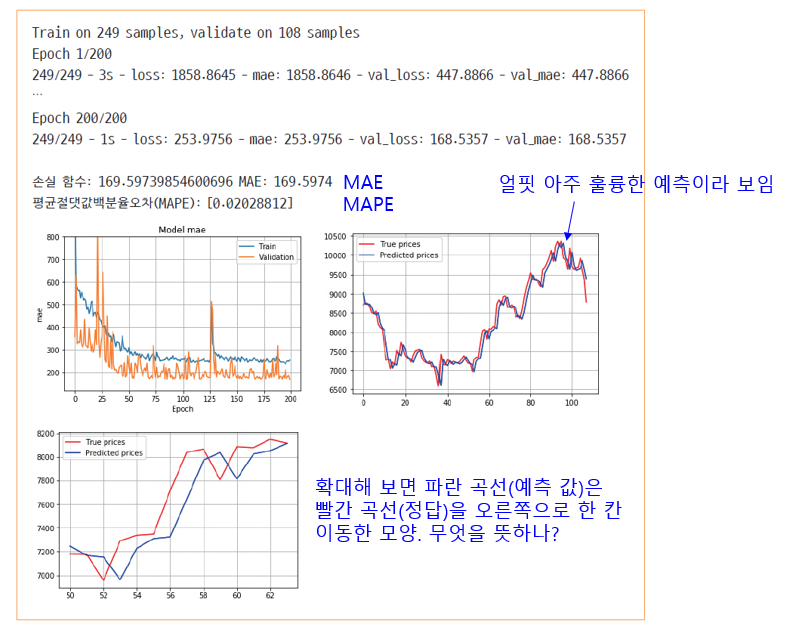

---

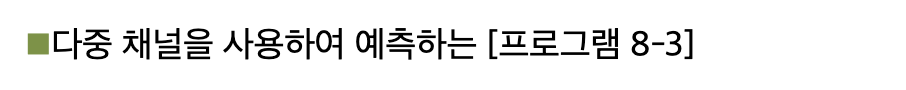

In [ ]:
# ------------------------------------------------------------
# [전체 개요: Overview]
# 본 코드는 코인데스크에서 제공하는 1년치 비트코인 가격 데이터를 기반으로,
# 종가, 시가, 고가, 저가 데이터를 입력으로 활용하여 LSTM(Long Short-Term Memory) 기반의
# 시계열 예측 모델을 학습시키고, 향후 하루의 가격을 예측하는 예제임.
# 데이터 전처리, 윈도우 분할, LSTM 모델 구성, 학습, 평가, 예측, 시각화의 전 과정을 포함함.
# ------------------------------------------------------------

# ------------------------------------------------------------
# [처리 흐름: Step-by-step Flow]
# 1단계: 필수 라이브러리 불러오기
# 2단계: CSV 파일로부터 시계열 데이터 로딩 및 배열 변환
# 3단계: 입력-타깃 변환 함수 정의
# 4단계: 윈도우 크기 및 수평선 설정 후 데이터셋 생성
# 5단계: 훈련/테스트 데이터 분할
# 6단계: LSTM 모델 구성 및 학습 수행
# 7단계: 모델 평가 및 예측 결과 출력
# 8단계: 학습 과정 시각화
# ------------------------------------------------------------

import numpy as np
# → 수치 계산을 위한 배열 연산 기능 제공용 NumPy 라이브러리 불러오기

import pandas as pd
# → 데이터프레임 형태로 데이터 처리 기능 제공용 Pandas 라이브러리 불러오기

import matplotlib.pyplot as plt
# → 학습 과정 및 예측 결과 시각화 기능 제공용 matplotlib.pyplot 모듈 불러오기

# ==============================
# 2단계: CSV 파일로부터 시계열 데이터 로딩 및 배열 변환
# ==============================
f = open("BTC_USD_2019-02-28_2020-02-27-CoinDesk.csv", "r")
# → 로컬에 저장된 비트코인 가격 CSV 파일을 읽기 모드로 열기

coindesk_data = pd.read_csv(f, header=0)
# → CSV 파일을 데이터프레임으로 읽어옴 (첫 번째 행을 열 이름으로 설정)

seq = coindesk_data[['Closing Price (USD)', '24h Open (USD)', '24h High (USD)', '24h Low (USD)']].to_numpy()
# → 종가, 시가, 고가, 저가 컬럼 선택 후 NumPy 배열로 변환

# ==============================
# 3단계: 입력-타깃 변환 함수 정의
# ==============================
def seq2dataset(seq, window, horizon):
    # → 시계열 데이터를 LSTM 입력 형식으로 변환하기 위한 사용자 정의 함수 정의
    X = []
    # → 입력 시퀀스 저장용 리스트 초기화
    Y = []
    # → 출력(타깃) 시퀀스 저장용 리스트 초기화
    for i in range(len(seq) - (window + horizon) + 1):
        # → 윈도우 및 수평선 길이를 고려한 유효 구간 순회
        x = seq[i:(i + window)]
        # → 윈도우 크기만큼 연속 데이터 슬라이싱하여 입력 생성
        y = seq[i + window + horizon - 1]
        # → horizon 이후 위치의 데이터를 타깃으로 설정
        X.append(x)
        # → 입력 시퀀스 리스트에 추가
        Y.append(y)
        # → 타깃 값 리스트에 추가
    return np.array(X), np.array(Y)
    # → 리스트를 NumPy 배열로 변환하여 반환

# ==============================
# 4단계: 윈도우 크기 및 수평선 설정 후 데이터셋 생성
# ==============================
w = 7
# → 과거 7일치 데이터를 기반으로 예측 수행하기 위해 윈도우 크기 설정

h = 1
# → 하루 뒤의 데이터를 예측하기 위한 수평선(horizon) 설정

X, Y = seq2dataset(seq, w, h)
# → 정의된 함수로 시계열 데이터를 입력-타깃 쌍으로 분할

print(X.shape, Y.shape)
# → 생성된 입력 및 타깃 배열의 형태 확인

print(X[0], Y[0])
# → 첫 번째 입력 시퀀스와 대응 타깃 값 확인

# ==============================
# 5단계: 훈련/테스트 데이터 분할
# ==============================
split = int(len(X) * 0.7)
# → 전체 데이터 중 70%를 훈련용으로 할당하기 위한 분할 인덱스 계산

x_train = X[0:split]
# → 훈련용 입력 데이터 설정

y_train = Y[0:split]
# → 훈련용 타깃 데이터 설정

x_test = X[split:]
# → 테스트용 입력 데이터 설정

y_test = Y[split:]
# → 테스트용 타깃 데이터 설정

from tensorflow.keras.models import Sequential
# → 순차형 모델 클래스 불러오기

from tensorflow.keras.layers import Dense, LSTM, Dropout
# → Dense, LSTM, Dropout 레이어 클래스 불러오기

# ==============================
# 6단계: LSTM 모델 구성 및 학습 수행
# ==============================
model = Sequential()
# → 순차적으로 레이어를 구성하기 위한 모델 인스턴스 생성

model.add(LSTM(units=128, activation='relu', input_shape=x_train[0].shape))
# → LSTM 레이어 추가 (유닛 수 128, 활성화 함수 ReLU, 입력 형태 설정)

model.add(Dense(4))
# → 출력 시 종가, 시가, 고가, 저가 예측을 위한 4개 유닛의 Dense 레이어 추가

model.compile(loss='mae', optimizer='adam', metrics=['mae'])
# → 손실 함수 MAE, 최적화 기법 Adam, 평가 지표 MAE 설정 후 모델 컴파일

hist = model.fit(x_train, y_train, epochs=200, batch_size=1, validation_data=(x_test, y_test), verbose=2)
# → 모델 학습 수행 (200 에폭, 배치 크기 1, 검증 데이터 포함, 로그 출력)

# ==============================
# 7단계: 모델 평가 및 예측 결과 출력
# ==============================
ev = model.evaluate(x_test, y_test, verbose=0)
# → 테스트셋을 활용한 모델 성능 평가 수행 (손실 MAE 반환)

print("손실 함수:", ev[0], "MAE:", ev[1])
# → 평가 결과(손실 값 및 MAE) 출력

pred = model.predict(x_test)
# → 학습된 모델을 사용하여 테스트 입력에 대한 예측 수행

print("LSTM 평균절댓값백분율오차(MAPE):", sum(abs(y_test - pred) / y_test) / len(x_test))
# → 전체 테스트셋에 대한 MAPE 수동 계산 및 출력

# ==============================
# 8단계: 학습 과정 시각화
# ==============================
plt.plot(hist.history['mae'])
# → 훈련 과정에서 MAE 변화 추세 시각화

plt.plot(hist.history['val_mae'])
# → 검증 과정에서 MAE 변화 추세 시각화

plt.title('Model mae')
# → 그래프 제목 설정

plt.ylabel('mae')
# → y축 라벨 설정

plt.xlabel('Epoch')
# → x축 라벨 설정

plt.ylim([100, 600])
# → y축 값 범위 제한 설정

plt.legend(['Train', 'Validation'], loc='best')
# → 훈련 및 검증 선 그래프 범례 설정

plt.grid()
# → 그래프 격자 표시 설정

plt.show()
# → 학습 곡선 그래프 출력


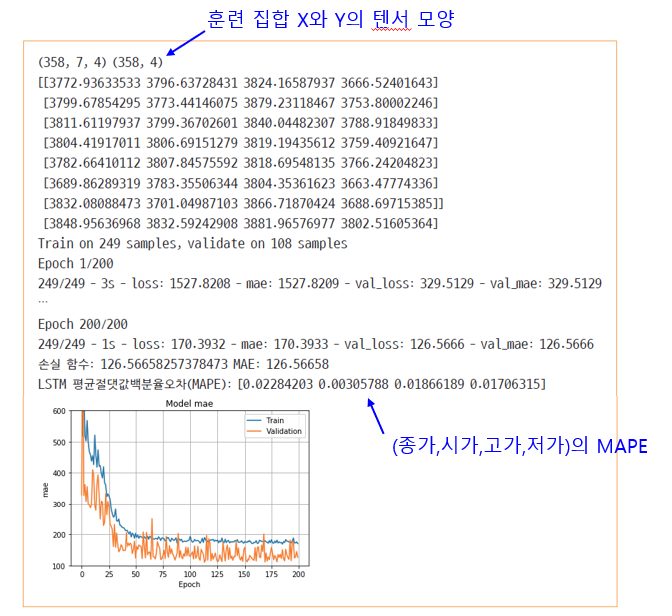

---

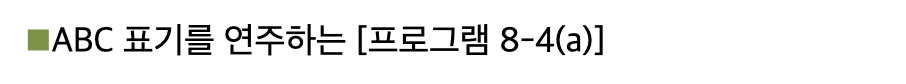

In [ ]:
import music21
# 음악 이론 분석, 악보 작성, MIDI 출력 등을 지원하는 파이썬 라이브러리 music21을 불러오기

# "작은 별" 악보를 ABC 표기로 표현
little_star = "tinynotation: 4/4 c4 c4 g4 g4 a4 a4 g2 f4 f4 e4 e4 d4 d4 c2 g4 g4 f4 f4 e4 e4 d2 g4 g4 f4 f4 e4 e4 d2 c4 c4 g4 g4 a4 a4 g2 f4 f4 e4 e4 d4 d4 c2"
# TinyNotation 형식을 사용해 '작은 별(반짝반짝 작은 별)' 멜로디를 문자열로 작성함
# "4/4"는 박자, 각 음표 뒤 숫자는 길이(4 = 4분음표, 2 = 2분음표)를 의미함
# 음계는 C major(다장조)를 기반으로 하며 영어 음 이름 사용(c, d, e, f, g, a, b)

music21.converter.parse(little_star).show('mid')
# 문자열로 표현한 TinyNotation 악보를 music21의 parser를 사용해 해석함
# 해석된 악보를 'mid'(MIDI) 형식으로 변환하여 디폴트 스피커를 통해 재생함
# 음악 이론이나 악보 없이도 코드만으로 멜로디를 청취할 수 있도록 하는 기능임

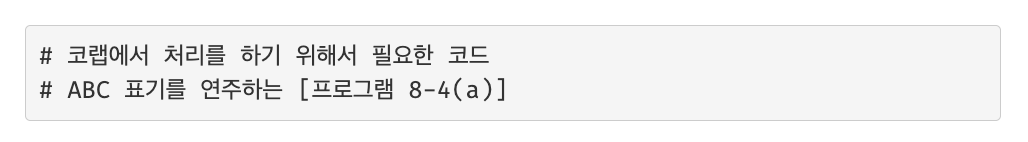

In [ ]:
# 코랩에서 처리를 하기 위해서 필요한 코드
# ABC 표기를 연주하는 [프로그램 8-4(a)]

# 필요한 패키지 설치
!pip install music21 pyfluidsynth
# music21(악보 분석 및 생성 라이브러리)과 pyfluidsynth(MIDI → 오디오 변환 도구)를 pip로 설치함

!apt-get install -y fluidsynth
# Ubuntu 기반 환경에서 fluidsynth 패키지를 시스템에 설치함
# fluidsynth는 사운드폰트를 이용하여 MIDI 파일을 실제 소리(WAV)로 합성하는 도구임

# 사운드폰트 다운로드
!wget -q https://github.com/urish/csound-fonts/raw/master/MuseScore_General.sf2 -O MuseScore_General.sf2
# MIDI를 실제 악기 소리처럼 변환하기 위한 사운드폰트(.sf2)를 지정된 URL에서 다운로드함
# MuseScore_General.sf2는 다양한 악기를 포함한 공개 사운드폰트임

from music21 import converter, midi
# music21의 악보 파서(converter)와 MIDI 관련 유틸리티 모듈 불러오기

import subprocess
# 외부 명령어 실행을 위한 subprocess 모듈 불러오기 (fluidsynth 호출에 사용 가능)

from IPython.display import Audio
# Colab 노트북 내에서 오디오 파일을 직접 재생하기 위한 Audio 클래스 불러오기

# 악보 파싱
little_star = "tinynotation: 4/4 c4 c4 g4 g4 a4 a4 g2 f4 f4 e4 e4 d4 d4 c2 g4 g4 f4 f4 e4 e4 d2 g4 g4 f4 f4 e4 e4 d2 c4 c4 g4 g4 a4 a4 g2 f4 f4 e4 e4 d4 d4 c2"
# TinyNotation을 사용하여 '반짝반짝 작은 별' 멜로디를 간단한 문자열 악보 형식으로 정의함

score = converter.parse(little_star)
# music21의 parser를 이용해 TinyNotation 문자열을 악보 객체로 변환함

# MIDI 저장
mf = midi.translate.music21ObjectToMidiFile(score)
# 악보 객체를 MIDI 파일 객체로 변환함

mf.open('little_star.mid', 'wb')
# 변환된 MIDI 파일을 '쓰기 모드(wb)'로 열어 저장할 준비를 함

mf.write()
# MIDI 데이터를 파일로 저장함

mf.close()
# 파일 저장을 완료하고 닫음

# MIDI → WAV (fluidsynth 사용)
!fluidsynth -ni MuseScore_General.sf2 little_star.mid -F little_star.wav -r 44100
# fluidsynth 명령어를 사용해 지정된 사운드폰트를 기반으로 MIDI 파일을 오디오(WAV) 파일로 변환함
# -ni: GUI 없이 실행, -F: 출력 WAV 파일 이름, -r: 샘플링 레이트(Hz)

# WAV 재생
Audio('little_star.wav')
# 생성된 WAV 파일을 노트북에서 직접 재생하기 위한 Audio 객체 생성 및 출력


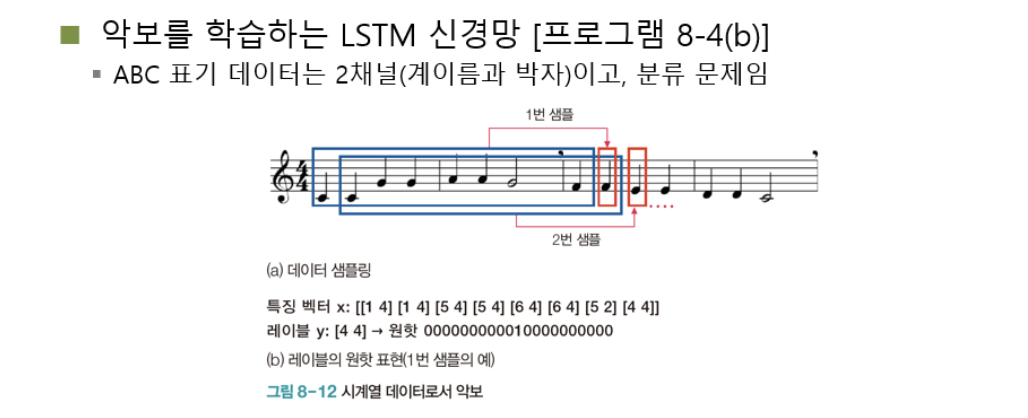

In [ ]:
# ------------------------------------------------------------
# [전체 개요: Overview]
# 본 코드는 딥러닝 기반 음악 편곡 시스템 예제임. TinyNotation으로 작성된 "작은 별"을 
# 시계열 데이터로 변환하여 LSTM(Long Short-Term Memory) 모델을 학습시킴. 이후 학습된
# 모델을 기반으로 새로운 멜로디 시퀀스를 생성하고, music21 라이브러리를 사용해 
# MIDI 파일로 재생함. 음악 데이터는 음높이와 길이의 조합으로 구성되며, 분류 문제로 접근함.
# ------------------------------------------------------------

# ------------------------------------------------------------
# [처리 흐름: Step-by-step Flow]
# 1단계: 계이름-숫자 변환 딕셔너리 정의
# 2단계: TinyNotation 문자열을 시계열로 변환하는 함수 정의
# 3단계: 시계열 데이터를 TinyNotation 문자열로 변환하는 함수 정의
# 4단계: 음높이+길이 조합에 대한 원핫 벡터 정의 및 변환 함수 정의
# 5단계: 시계열 데이터를 LSTM 입력용 윈도우로 분할하는 함수 정의
# 6단계: 데이터 준비 및 LSTM 모델 학습
# 7단계: 학습된 모델로 음악 시퀀스를 생성하는 함수 정의 및 결과 출력
# ------------------------------------------------------------

import numpy as np
# 수치 연산 및 배열 처리를 위한 NumPy 라이브러리 불러오기

# 계이름과 숫자를 상호 변환하는 표(딕셔너리 자료구조를 사용함)
note2num = {'c':1, 'd':2, 'e':3, 'f':4, 'g':5, 'a':6, 'b':7}
# 계이름을 숫자로 변환하기 위한 딕셔너리 정의

num2note = {1:'c', 2:'d', 3:'e', 4:'f', 5:'g', 6:'a', 7:'b'}
# 숫자를 계이름으로 변환하기 위한 딕셔너리 정의

# ABC 표기를 시계열 데이터로 변환
def abc2timeseries(s):
    notes = s.split(' ')[2:]
    # TinyNotation 문자열에서 타임시그니처를 제외한 음표 부분만 추출
    seq = []
    for i in notes:
        seq.append([note2num[i[0]], int(i[1])])
        # 각 음표의 계이름과 길이를 숫자로 변환하여 리스트에 저장
    return seq
    # 시계열 데이터로 변환된 음표 시퀀스 반환

# 시계열 데이터를 ABC 표기로 변환
def timeseries2abc(t):
    s = 'tinynotation: 4/4'
    # 타임 시그니처 포함한 TinyNotation 시작 문자열 정의
    for i in t:
        s = s + ' ' + num2note[i[0]] + str(i[1])
        # 숫자를 계이름으로 바꾸고 길이를 붙여 문자열로 변환
    return s
    # 최종 ABC 문자열 반환

# 원핫 코드로 변환하는 표
onehot = [[i, d] for d in [2,4,8] for i in range(1,8)]
# 계이름(1~7)과 길이(2, 4, 8)의 조합을 모두 포함하는 리스트 정의

# 레이블을 원핫 코드로 변환
def to_onehot(l):
    t = []
    for i in range(len(l)):
        a = np.zeros(len(onehot))
        # onehot 벡터 길이만큼 0으로 채운 벡터 생성
        a[onehot.index(list(l[i]))] = 1.0
        # 해당 음표(음높이+길이) 조합의 인덱스에 1 할당
        t.append(a)
    return np.array(t)
    # 모든 변환 결과를 배열 형태로 반환

# 시계열 데이터를 훈련 집합으로 자름
def seq2dataset(seq, window, horizon):
    X = []
    Y = []
    for i in range(len(seq) - (window + horizon) + 1):
        x = seq[i:(i + window)]
        # 윈도우 크기만큼 슬라이싱하여 입력 시퀀스 생성
        y = seq[i + window + horizon - 1]
        # 윈도우 이후 horizon 거리만큼 떨어진 음표를 타깃값으로 설정
        X.append(x)
        Y.append(y)
    return np.array(X), np.array(Y)
    # 입력(X)과 타깃(Y)을 배열로 반환

w = 8
# LSTM의 입력 시퀀스 길이를 8개 음표로 설정

h = 1
# 1개 음표 이후의 결과를 예측 대상으로 설정

seq = abc2timeseries(little_star)
# '작은 별' ABC 표기를 시계열 데이터로 변환

X, Y = seq2dataset(seq, w, h)
# 윈도우 기반으로 입력-타깃 쌍으로 분할

print(X.shape, Y.shape)
# 입력 및 타깃 데이터의 차원 출력

print(X[0], Y[0])
# 첫 번째 샘플과 해당 타깃 출력

from tensorflow.keras.models import Sequential
# 순차적 딥러닝 모델을 구성하기 위한 Keras의 Sequential 클래스 불러오기

from tensorflow.keras.layers import Dense, LSTM
# LSTM 및 Dense 레이어 불러오기

import tensorflow as tf
# 텐서플로우 메인 모듈 불러오기

# 훈련 집합 구축
split = int(len(X) * 1.0)
# 전체 데이터셋의 100%를 훈련에 사용함

x_train = X[0:split]
# 훈련용 입력 시퀀스 설정

y_train = Y[0:split]
# 훈련용 타깃값 설정

y_train = to_onehot(y_train)
# 타깃값을 원핫 인코딩하여 분류 문제에 맞게 변환

# LSTM 모델 설계와 학습
model = Sequential()
# 순차 모델 인스턴스 생성

model.add(LSTM(units=128, activation='relu', input_shape=x_train[0].shape))
# LSTM 레이어 추가, 셀 개수는 128개, ReLU 활성화 함수 사용, 입력 형태 지정

model.add(Dense(y_train.shape[1], activation='softmax'))
# 출력층 설정, 가능한 음표 조합 수만큼 유닛을 갖고 softmax로 다중 클래스 확률 분포 출력

model.compile(loss='categorical_crossentropy', optimizer='Adam', metrics=['accuracy'])
# 손실 함수는 categorical crossentropy, 최적화는 Adam, 평가 지표는 정확도로 설정

model.fit(x_train, y_train, epochs=200, batch_size=1, verbose=2)
# 모델 학습 수행 (에폭 200회, 배치 크기 1)

# 학습된 모델로 편곡을 하는 함수(first_measure: 첫 소절, duration: 생성될 곡의 길이)
def arranging_music(model, first_measure, duration):
    music = first_measure
    for i in range(duration):
        p = model.predict(np.float32(np.expand_dims(music[-w:], axis=0)))
        # 최근 w개 시퀀스를 모델 입력으로 하여 다음 음표를 예측함
        music = np.append(music, [onehot[np.argmax(p)]], axis=0)
        # 예측된 음표(가장 확률 높은 인덱스)를 기존 시퀀스에 추가
    return timeseries2abc(music)
    # 최종 생성된 시퀀스를 TinyNotation 문자열로 변환하여 반환

new_song = arranging_music(model, x_train[0], 50)
# 훈련셋 첫 소절을 기반으로 50개의 음표를 생성하여 새로운 곡 생성

print(new_song)
# 생성된 곡의 TinyNotation 문자열 출력

music21.converter.parse(new_song).show('mid')
# music21을 이용해 생성된 음악을 MIDI로 재생


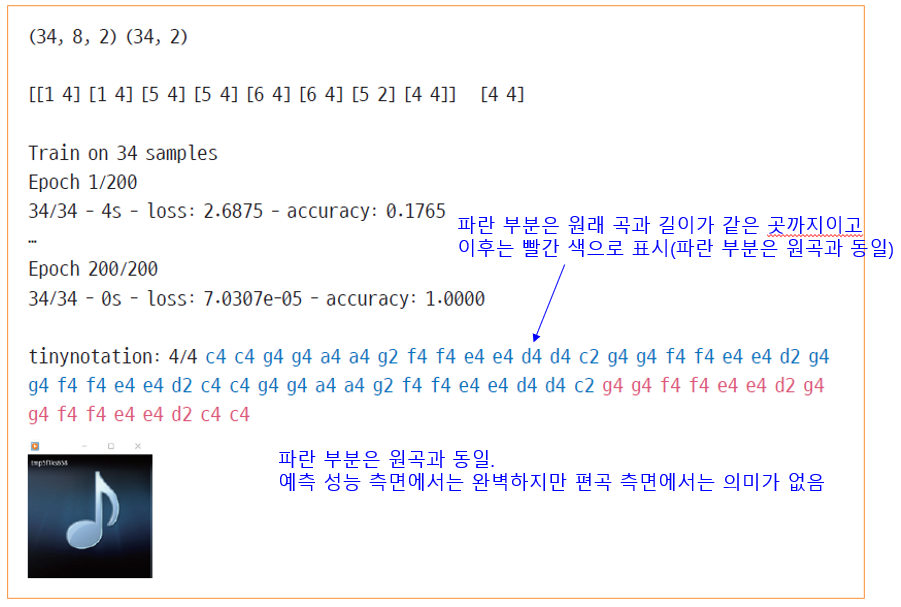

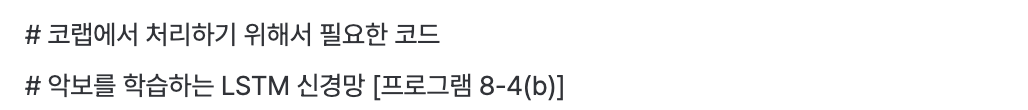

In [ ]:
# ------------------------------------------------------------
# [전체 개요: Overview]
# 본 코드는 LSTM(Long Short-Term Memory) 신경망 모델을 활용하여
# ABC 악보 표기법 데이터를 시계열로 변환하여 학습한 후, 학습된 모델을 기반으로
# 새로운 멜로디를 자동으로 생성하고, 이를 악보 시각화 및 오디오 파일(WAV)로 변환하여
# Google Colab 환경에서 재생 및 저장까지 수행하는 예제임.
# ------------------------------------------------------------

# ------------------------------------------------------------
# [처리 흐름: Step-by-step Flow]
# 1단계: 패키지 설치 및 SoundFont 다운로드
# 2단계: 라이브러리 임포트 및 악보 ↔ 숫자 변환 테이블 정의
# 3단계: ABC 표기법 ↔ 시계열 데이터 변환 함수 정의
# 4단계: 시계열 데이터 → ABC 표기법 변환 함수 정의
# 5단계: 원-핫 인코딩 테이블 및 변환 함수 정의
# 6단계: 시계열 데이터 윈도우 생성 함수 정의
# 7단계: 전처리 및 학습용 데이터셋 구성
# 8단계: LSTM 모델 구성 및 학습
# 9단계: 음악 생성 함수 정의 및 새로운 곡 생성
# 10단계: 악보 시각화 및 플롯 저장
# 11단계: MIDI → WAV 변환 및 오디오 재생
# ------------------------------------------------------------

# ==============================
# 1단계: 패키지 설치 및 SoundFont 다운로드
# ==============================
!apt-get install -y fluidsynth
# → FluidSynth 설치 명령어 실행
!pip install midi2audio
# → midi2audio 라이브러리 설치 명령어 실행
!wget -O /usr/share/sounds/sf2/MusyngKite.sf2 \
    https://github.com/urish/midi2audio/raw/master/examples/soundfonts/MusyngKite.sf2
# → SoundFont 파일 다운로드

# ==============================
# 2단계: 라이브러리 임포트 및 악보 ↔ 숫자 변환 테이블 정의
# ==============================
import numpy as np
# → 수치 연산용 NumPy 라이브러리 임포트
from music21 import converter
# → ABC → 악보 객체 변환용 music21 모듈 임포트
from IPython.display import Audio, Image, display
# → Colab 내 미디어 출력용 모듈 임포트
import matplotlib.pyplot as plt
# → 시각화용 Matplotlib 모듈 임포트
from midi2audio import FluidSynth
# → MIDI → WAV 변환용 FluidSynth 클래스 임포트
import os
# → 파일 시스템 경로 처리용 os 모듈 임포트

note2num = {'c': 1, 'd': 2, 'e': 3, 'f': 4, 'g': 5, 'a': 6, 'b': 7}
# → 음표 문자 → 숫자 매핑 사전
num2note = {v: k for k, v in note2num.items()}
# → 숫자 → 음표 문자 매핑 사전 자동 생성

# ==============================
# 3단계: ABC 표기법 ↔ 시계열 데이터 변환 함수 정의
# ==============================
def abc2timeseries(s):
    notes = s.split(' ')[2:]
    # → ABC 문자열에서 실제 음표 구간 분리 처리
    seq = []
    # → 변환 결과 저장용 리스트 초기화
    for note in notes:
        pitch = note2num[note[0]]
        # → 음표 문자 → 숫자 변환
        duration = int(note[1])
        # → 음표 길이(박자) 정수 변환
        seq.append([pitch, duration])
        # → 피치 및 길이 쌍 형태로 기록
    return seq
    # → 시계열 데이터 리스트 반환

def timeseries2abc(t):
    s = 'tinynotation: 4/4'
    # → ABC 표기법 헤더 초기화
    for pitch, duration in t:
        s += f' {num2note[pitch]}{duration}'
        # → 숫자 → 음표 문자 및 길이 결합
    return s
    # → 완성된 ABC 문자열 반환

# ==============================
# 4단계: 원-핫 인코딩 테이블 및 변환 함수 정의
# ==============================
onehot = [[note, dur] for dur in [2, 4, 8] for note in range(1, 8)]
# → 모든 피치·길이 조합 원-핫 인덱스 테이블

def to_onehot(sequence):
    t = []
    # → 변환 결과 저장용 리스트 초기화
    for elem in sequence:
        vector = np.zeros(len(onehot))
        # → 원-핫 벡터 초기화
        idx = onehot.index(list(elem))
        # → 해당 피치·길이에 매핑되는 인덱스 검색
        vector[idx] = 1.0
        # → 해당 위치에 1 설정
        t.append(vector)
        # → 벡터 형태로 결과 저장
    return np.array(t)
    # → NumPy 배열 형태로 반환

# ==============================
# 5단계: 시계열 데이터 윈도우 생성 함수 정의
# ==============================
def seq2dataset(seq, window, horizon):
    X, Y = [], []
    # → 입력(X) 및 정답(Y) 저장용 리스트 초기화
    for i in range(len(seq) - window - horizon + 1):
        x = seq[i : i + window]
        # → 윈도우 길이만큼 입력 시퀀스 추출
        y = seq[i + window + horizon - 1]
        # → horizon 위치의 예측 대상 음표 추출
        X.append(x)
        # → 입력 시퀀스 추가
        Y.append(y)
        # → 예측 대상 추가
    return np.array(X), np.array(Y)
    # → NumPy 배열 형태로 반환

# ==============================
# 6단계: 전처리 및 학습용 데이터셋 구성
# ==============================
little_star = (
    "tinynotation: 4/4 c4 c4 g4 g4 a4 a4 g2 f4 f4 e4 e4 d4 d4 c2 "
    "g4 g4 f4 f4 e4 e4 d2 g4 g4 f4 f4 e4 e4 d2 c4 c4 g4 g4 a4 a4 g2 "
    "f4 f4 e4 e4 d4 d4 c2"
)
# → 학습용 원본 곡 ABC 문자열 정의
w, h = 8, 1
# → 입력 윈도우 크기 및 예측 지점 설정
seq = abc2timeseries(little_star)
# → ABC → 시계열 데이터 변환
X, Y = seq2dataset(seq, w, h)
# → 윈도우별 학습 데이터셋 생성
x_train = X
# → 입력 데이터 바인딩
y_train = to_onehot(Y)
# → 정답 데이터 원-핫 인코딩 변환

# ==============================
# 7단계: LSTM 모델 구성 및 학습
# ==============================
from tensorflow.keras.models import Sequential
# → 모델 구성용 Sequential 클래스 임포트
from tensorflow.keras.layers import Dense, LSTM
# → Dense·LSTM 레이어 클래스 임포트

model = Sequential()
# → 순차 모델 객체 생성
model.add(LSTM(units=128, activation='relu', input_shape=x_train[0].shape))
# → LSTM 레이어 추가
model.add(Dense(y_train.shape[1], activation='softmax'))
# → 출력 레이어 추가
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
# → 모델 컴파일
model.fit(x_train, y_train, epochs=200, batch_size=1, verbose=0)
# → 모델 학습 실행

# ==============================
# 8단계: 음악 생성 함수 정의 및 새로운 곡 생성
# ==============================
def arranging_music(model, first_measure, duration):
    music = first_measure.copy()
    # → 초기 시퀀스 복사
    for _ in range(duration):
        input_seq = np.expand_dims(music[-w:], axis=0).astype(np.float32)
        # → 입력 형식 변환
        probs = model.predict(input_seq, verbose=0)
        # → 다음 음표 예측 확률 분포 계산
        next_idx = np.argmax(probs)
        # → 확률 최대 인덱스 선택
        music = np.vstack([music, onehot[next_idx]])
        # → 예측 음표 원-핫으로 추가
    return timeseries2abc(music)
    # → 최종 시퀀스를 ABC 문자열로 변환하여 반환

new_song = arranging_music(model, x_train[0], 50)
# → 50음표 길이의 새로운 곡 생성
print("[Generated ABC Notation]")
# → ABC 문자열 출력 안내
print(new_song)
# → 생성된 ABC 문자열 출력

# ==============================
# 9단계: 악보 시각화 및 플롯 저장
# ==============================
score = converter.parse(new_song)
# → ABC 문자열 → music21 악보 객체 변환
notes = abc2timeseries(new_song)
# → 악보 객체로부터 시계열 데이터 재생성
pitches = [note[0] for note in notes]
# → 피치 정보만 추출

plt.figure(figsize=(12, 2))
# → 플롯 크기 설정
plt.plot(pitches, marker='o', linestyle='-')
# → 피치 시퀀스 선 그래프 출력
plt.title("Generated Melody (Pitch Sequence)")
# → 그래프 제목 설정
plt.xlabel("Note Index")
# → x축 라벨 설정
plt.ylabel("Pitch (1~7)")
# → y축 라벨 설정
plt.xticks(np.arange(len(pitches)))
# → x축 눈금 설정
plt.yticks(np.arange(1, 8))
# → y축 눈금 설정
plt.grid(True)
# → 그리드 표시
img_path = os.path.join(save_dir, 'generated_score.png')
# → 악보 이미지 경로 설정
plt.savefig(img_path)
# → 플롯 이미지 파일 저장
plt.show()
# → 플롯 표시

display(Image(img_path))
# → Colab 환경에서 이미지 출력

# ==============================
# 10단계: MIDI → WAV 변환 및 오디오 재생
# ==============================
midi_path = os.path.join(save_dir, 'generated_song.mid')
# → MIDI 파일 경로 설정
score.write('midi', fp=midi_path)
# → 악보 객체 → MIDI 파일 저장
wav_path = os.path.join(save_dir, 'generated_song.wav')
# → WAV 파일 경로 설정
fs = FluidSynth('/usr/share/sounds/sf2/MusyngKite.sf2')
# → FluidSynth 객체 초기화
fs.midi_to_audio(midi_path, wav_path)
# → MIDI → WAV 변환 수행
display(Audio(wav_path))
# → Colab 환경에서 WAV 오디오 재생


---

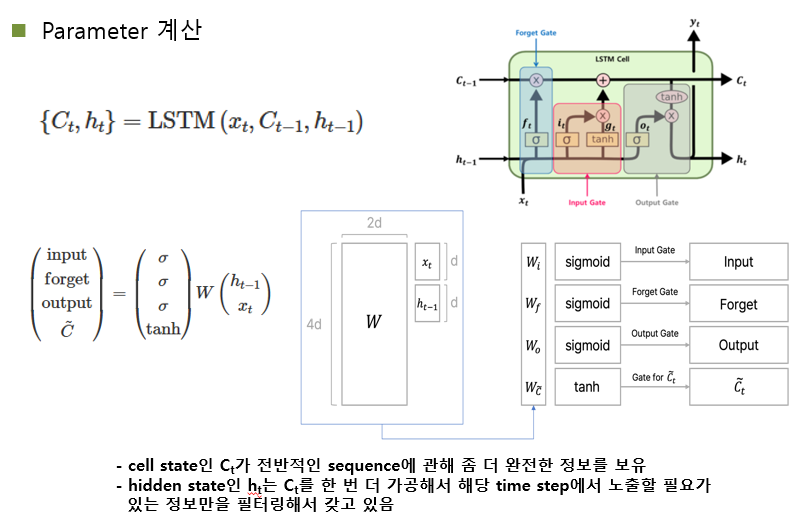

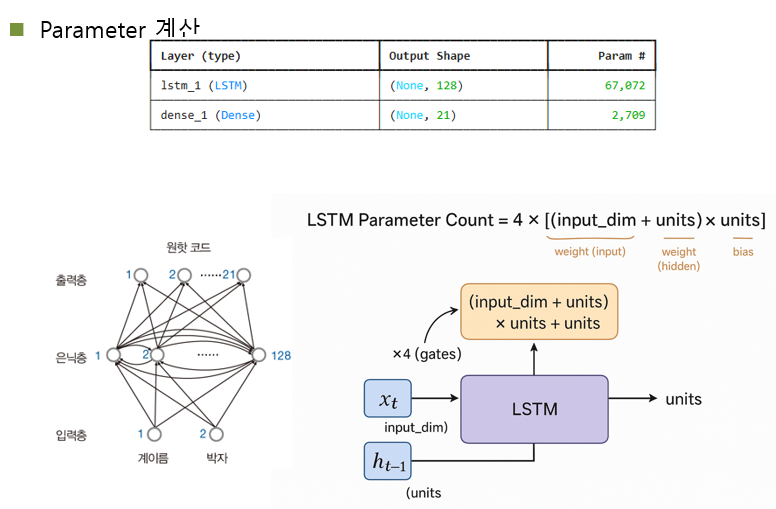

---

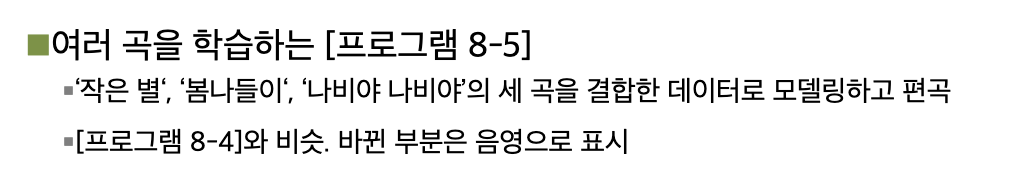

In [ ]:
# ------------------------------------------------------------
# [전체 개요: Overview]
# 본 코드는 '작은 별', '봄나들이', '나비야 나비야' 세 곡의 ABC 악보를 시계열 데이터로 변환하여
# 결합한 후, LSTM(Long Short-Term Memory) 신경망 기반 음악 생성 모델을 학습시키고,
# 학습된 모델을 활용해 새로운 멜로디를 자동으로 생성하는 예제임.
# 데이터 전처리, 원-핫 인코딩, 윈도우 분할, 모델 구성, 학습, 음악 생성 과정을 포함함.
# ------------------------------------------------------------

# ------------------------------------------------------------
# [처리 흐름: Step-by-step Flow]
# 1단계: music21 라이브러리 및 ABC 악보 데이터 정의
# 2단계: 변환용 딕셔너리 및 변환 함수 정의
# 3단계: 원-핫 인코딩 테이블 및 변환 함수 정의
# 4단계: 시계열 데이터 윈도우 분할 함수 정의
# 5단계: 세 곡 시계열 데이터 결합 및 학습용 데이터셋 생성
# 6단계: LSTM 모델 구성 및 학습 수행
# 7단계: 편곡 함수 정의 및 새로운 곡 생성
# ------------------------------------------------------------

import music21
# → 음악 악보 파싱 기능 제공용 music21 라이브러리 불러오기

# ==============================
# 1단계: music21 라이브러리 및 ABC 악보 데이터 정의
# ==============================
little_star = "tinynotation: 4/4 c4 c4 g4 g4 a4 a4 g2 f4 f4 e4 e4 d4 d4 c2 g4 g4 f4 f4 e4 e4 d2 g4 g4 f4 f4 e4 e4 d2 c4 c4 g4 g4 a4 a4 g2 f4 f4 e4 e4 d4 d4 c2"
# → '작은 별' 곡의 ABC 표기 문자열 정의
spring_picnic = "tinynotation: 4/8 g8 e8 g8 e8 g8 a8 g4 e8 g8 e8 c8 d8 e8 c4 g8 e8 g8 e8 g8 a8 g4 b8 a8 g8 e8 d8 e8 c4"
# → '봄나들이' 곡의 ABC 표기 문자열 정의
butterfly = "tinynotation: 2/4 g8 e8 e4 f8 d8 d4 c8 d8 e8 f8 g8 g8 g4 g8 e8 e8 e8 f8 d8 d4 c8 e8 g8 g8 e8 e8 e4 d8 d8 d8 d8 d8 e8 f4 e8 e8 e8 e8 e8 f8 g4 g8 e8 e4 f8 d8 d4 c8 e8 g8 g8 e8 e8 e4"
# → '나비야 나비야' 곡의 ABC 표기 문자열 정의

import numpy as np
# → 수치 연산용 NumPy 라이브러리 불러오기

# ==============================
# 2단계: 변환용 딕셔너리 및 변환 함수 정의
# ==============================
note2num = {'c':1,'d':2,'e':3,'f':4,'g':5,'a':6,'b':7}
# → 음표 문자 → 숫자 매핑 사전 정의
num2note = {v:k for k,v in note2num.items()}
# → 숫자 → 음표 문자 매핑 사전 자동 생성

def abc2timeseries(s):
    # → ABC 표기 문자열을 시계열 리스트로 변환하기 위한 함수 정의
    notes = s.split(' ')[2:]
    # → 헤더 이후 실제 음표 구간 분리 처리
    seq = []
    # → 변환 결과 저장용 리스트 초기화
    for note in notes:
        pitch = note2num[note[0]]
        # → 음표 문자에서 숫자로 변환
        duration = int(note[1])
        # → 숫자 부분을 정수로 변환
        seq.append([pitch, duration])
        # → 피치 및 길이 쌍 형태로 리스트에 추가
    return seq
    # → 완성된 시계열 리스트 반환

def timeseries2abc(t):
    # → 시계열 리스트를 ABC 표기 문자열로 변환하기 위한 함수 정의
    s = 'tinynotation: 4/4'
    # → 기본 ABC 헤더 초기화
    for pitch, duration in t:
        s += f' {num2note[pitch]}{duration}'
        # → 숫자→음표 문자 및 길이 결합
    return s
    # → 완성된 ABC 표기 문자열 반환

# ==============================
# 3단계: 원-핫 인코딩 테이블 및 변환 함수 정의
# ==============================
onehot = [[n,d] for d in [2,4,8] for n in range(1,8)]
# → 피치·길이 조합의 원-핫 인덱스 테이블 정의

def to_onehot(sequence):
    # → 시계열 레이블을 원-핫 벡터로 변환하기 위한 함수 정의
    t = []
    # → 변환 결과 저장용 리스트 초기화
    for elem in sequence:
        vector = np.zeros(len(onehot))
        # → 길이(len)만큼 영벡터 생성
        idx = onehot.index(list(elem))
        # → 레이블에 해당하는 인덱스 검색
        vector[idx] = 1.0
        # → 해당 위치에 1 설정
        t.append(vector)
        # → 벡터를 리스트에 추가
    return np.array(t)
    # → NumPy 배열로 변환하여 반환

# ==============================
# 4단계: 시계열 데이터 윈도우 분할 함수 정의
# ==============================
def seq2dataset(seq, window, horizon):
    # → LSTM 입력용 윈도우 분할 함수 정의
    X, Y = [], []
    # → 입력(X), 출력(Y) 리스트 초기화
    for i in range(len(seq) - (window + horizon) + 1):
        x = seq[i:(i + window)]
        # → 윈도우 크기만큼 연속 데이터 추출
        y = seq[i + window + horizon - 1]
        # → horizon 뒤 위치의 시점 레이블 추출
        X.append(x)
        # → 입력 리스트에 추가
        Y.append(y)
        # → 출력 리스트에 추가
    return np.array(X), np.array(Y)
    # → NumPy 배열 형태로 반환

# ==============================
# 5단계: 세 곡 시계열 데이터 결합 및 학습용 데이터셋 생성
# ==============================
seq1 = abc2timeseries(little_star)
# → '작은 별' 곡 시계열 변환
seq2 = abc2timeseries(butterfly)
# → '나비야 나비야' 곡 시계열 변환
seq3 = abc2timeseries(spring_picnic)
# → '봄나들이' 곡 시계열 변환
seq = seq1 + seq2 + seq3
# → 세 곡 시계열 데이터를 순차적으로 결합

w, h = 8, 1
# → 윈도우 크기와 예측 수평선 설정
X, Y = seq2dataset(seq, w, h)
# → 윈도우 분할을 통해 입력-출력 쌍 생성

# ==============================
# 6단계: LSTM 모델 구성 및 학습 수행
# ==============================
from tensorflow.keras.models import Sequential
# → 순차형 모델 클래스 불러오기
from tensorflow.keras.layers import Dense, LSTM
# → Dense, LSTM 레이어 클래스 불러오기
import tensorflow as tf
# → TensorFlow 라이브러리 전체 임포트

split = len(X)
# → 전체 데이터를 학습용으로 사용하기 위한 분할 크기 설정
x_train, y_train = X[:split], Y[:split]
# → 입력 및 레이블 학습용 데이터 설정
y_train = to_onehot(y_train)
# → 학습용 레이블을 원-핫 벡터로 변환

model = Sequential()
# → 순차 모델 인스턴스 생성
model.add(LSTM(units=128, activation='relu', input_shape=x_train[0].shape))
# → LSTM 레이어 추가 (유닛 128, 활성화 함수 ReLU, 입력 형태 설정)
model.add(Dense(y_train.shape[1], activation='softmax'))
# → 출력 레이어 추가 (소프트맥스 활성화 함수)
model.compile(loss='categorical_crossentropy', optimizer='Adam', metrics=['accuracy'])
# → 손실 함수, 최적화 기법, 평가 지표 설정 및 모델 컴파일
model.fit(x_train, y_train, epochs=200, batch_size=1, verbose=2)
# → 모델 학습 수행 (200 에폭, 배치 크기 1, 상세 로그 출력)

# ==============================
# 7단계: 편곡 함수 정의 및 새로운 곡 생성
# ==============================
def arranging_music(model, first_measure, duration):
    # → 학습된 모델 기반 음악 생성 함수 정의
    music = first_measure.copy()
    # → 초기 시퀀스(첫마디) 복사
    for _ in range(duration):
        p = model.predict(np.float32(np.expand_dims(music[-w:], axis=0)))
        # → 최근 w개 윈도우 입력에 대한 예측 확률 분포 생성
        next_onehot = onehot[np.argmax(p)]
        # → 최대 확률 인덱스의 원-핫 벡터 선택
        music = np.append(music, [next_onehot], axis=0)
        # → 예측 결과를 시퀀스에 추가
    return timeseries2abc(music)
    # → 최종 시퀀스를 ABC 표기 문자열로 변환하여 반환

new_song = arranging_music(model, X[0], 50)
# → 학습된 모델로 50음표 길이의 새로운 곡 생성
print(new_song)
# → 생성된 ABC 표기 문자열 출력
music21.converter.parse(new_song).show('mid')
# → 음악 악보 객체를 MIDI로 출력하여 재생 형태로 시각화


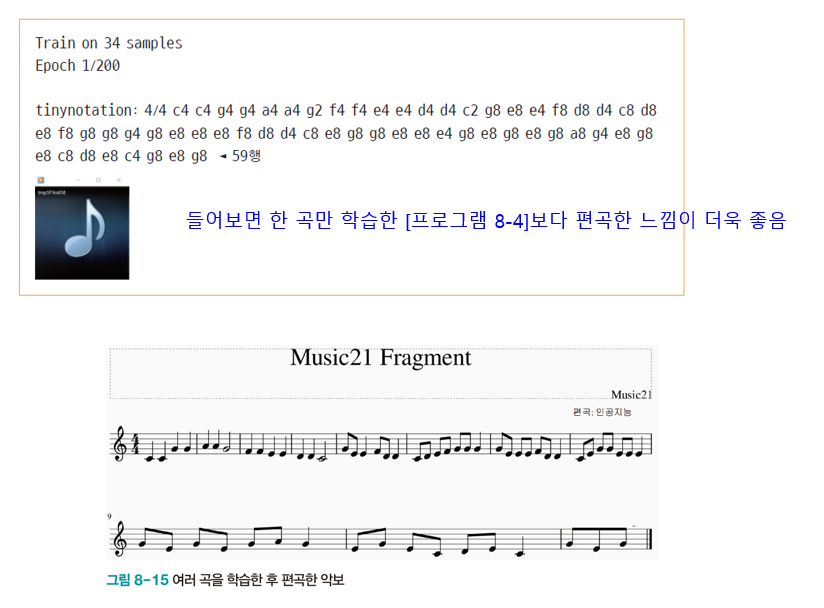

In [ ]:
# ------------------------------------------------------------
# [전체 개요: Overview]
# 본 코드는 '작은 별', '봄나들이', '나비야 나비야' 세 곡의 ABC 악보 데이터를 결합하여
# LSTM(Long Short-Term Memory) 신경망 기반의 음악 생성 모델을 학습하고,
# 학습된 모델을 활용하여 새로운 멜로디를 자동으로 생성하는 예제임.
# Google Colab 환경에서 데이터를 처리하고, 생성된 악보를 MIDI 및 WAV 파일로 저장하며,
# 피치 시퀀스를 시각화하여 결과를 확인할 수 있도록 구현됨.
# ------------------------------------------------------------

# ------------------------------------------------------------
# [처리 흐름: Step-by-step Flow]
# 1단계: 라이브러리 임포트 및 ABC 악보 문자열 정의
# 2단계: 음표 ↔ 숫자 변환용 딕셔너리 및 변환 함수 정의
# 3단계: 원-핫 인코딩 테이블 및 변환 함수 정의
# 4단계: 시계열 윈도우 분할 함수 정의
# 5단계: 세 곡 시계열 데이터 결합 및 학습용 데이터셋 생성
# 6단계: LSTM 모델 구성 및 학습 수행
# 7단계: 편곡 함수 정의 및 새로운 곡 생성
# 8단계: 생성된 악보 MIDI 및 WAV 파일 저장
# 9단계: 피치 시퀀스 시각화 및 결과 출력
# ------------------------------------------------------------

import music21
# → 음악 악보 파싱 및 MIDI 변환 기능 제공용 music21 라이브러리 임포트
import numpy as np
# → 수치 연산을 위한 NumPy 라이브러리 임포트
import os
# → 파일 시스템 작업을 위한 os 모듈 임포트
from IPython.display import Audio, Image, display
# → Colab 환경에서 오디오 및 이미지 출력 기능 제공용 모듈 임포트
import matplotlib.pyplot as plt
# → 결과 시각화를 위한 matplotlib.pyplot 모듈 임포트
from midi2audio import FluidSynth
# → MIDI → WAV 변환 기능 제공용 FluidSynth 클래스 임포트
from tensorflow.keras.models import Sequential
# → 순차형 딥러닝 모델 클래스 임포트
from tensorflow.keras.layers import Dense, LSTM
# → Dense 및 LSTM 레이어 클래스 임포트

# ==============================
# 1단계: 라이브러리 임포트 및 ABC 악보 문자열 정의
# ==============================
little_star = "tinynotation: 4/4 c4 c4 g4 g4 a4 a4 g2 f4 f4 e4 e4 d4 d4 c2 g4 g4 f4 f4 e4 e4 d2 g4 g4 f4 f4 e4 e4 d2 c4 c4 g4 g4 a4 a4 g2 f4 f4 e4 e4 d4 d4 c2"
# → '작은 별' 곡의 ABC 표기 문자열 정의
spring_picnic = "tinynotation: 4/8 g8 e8 g8 e8 g8 a8 g4 e8 g8 e8 c8 d8 e8 c4 g8 e8 g8 e8 g8 a8 g4 b8 a8 g8 e8 d8 e8 c4"
# → '봄나들이' 곡의 ABC 표기 문자열 정의
butterfly = "tinynotation: 2/4 g8 e8 e4 f8 d8 d4 c8 d8 e8 f8 g8 g8 g4 g8 e8 e8 e8 f8 d8 d4 c8 e8 g8 g8 e8 e8 e4 d8 d8 d8 d8 d8 e8 f4 e8 e8 e8 e8 e8 f8 g4 g8 e8 e4 f8 d8 d4 c8 e8 g8 g8 e8 e8 e4"
# → '나비야 나비야' 곡의 ABC 표기 문자열 정의

# ==============================
# 2단계: 음표 ↔ 숫자 변환용 딕셔너리 및 변환 함수 정의
# ==============================
note2num = {'c':1, 'd':2, 'e':3, 'f':4, 'g':5, 'a':6, 'b':7}
# → 음표 문자에서 숫자로 변환하기 위한 매핑 사전 정의
num2note = {v:k for k,v in note2num.items()}
# → 숫자에서 음표 문자로 변환하기 위한 매핑 사전 자동 생성

def abc2timeseries(s):
    notes = s.split(' ')[2:]
    # → ABC 헤더 이후 실제 음표 구간 분리
    seq = []
    # → 변환된 시계열 데이터를 저장할 리스트 초기화
    for n in notes:
        seq.append([note2num[n[0]], int(n[1])])
        # → 각 음표 문자 및 길이를 숫자와 정수로 변환하여 리스트에 추가
    return seq
    # → 완성된 시계열 리스트 반환

def timeseries2abc(t):
    s = 'tinynotation: 4/4'
    # → ABC 헤더 초기화
    for pitch, dur in t:
        s += ' ' + num2note[pitch] + str(dur)
        # → 피치 숫자를 음표 문자로 변환하고 길이를 결합하여 문자열에 추가
    return s
    # → 완성된 ABC 문자열 반환

# ==============================
# 3단계: 원-핫 인코딩 테이블 및 변환 함수 정의
# ==============================
onehot = [[n, d] for d in [2,4,8] for n in range(1,8)]
# → 가능한 피치·길이 조합을 원-핫 인덱스 리스트로 정의

def to_onehot(labels):
    return np.array([
        np.eye(len(onehot))[onehot.index(list(lbl))]
        for lbl in labels
    ])
    # → 각 레이블을 일대일 매핑하여 원-핫 벡터로 변환한 NumPy 배열 반환

# ==============================
# 4단계: 시계열 윈도우 분할 함수 정의
# ==============================
def seq2dataset(seq, window, horizon):
    X, Y = [], []
    # → 입력(X) 및 타깃(Y) 리스트 초기화
    for i in range(len(seq) - (window + horizon) + 1):
        X.append(seq[i:i+window])
        # → window 길이만큼 슬라이싱하여 입력 시퀀스 생성
        Y.append(seq[i+window+horizon-1])
        # → horizon 이후 위치의 데이터 포인트를 타깃으로 추가
    return np.array(X), np.array(Y)
    # → NumPy 배열 형태로 반환

# ==============================
# 5단계: 세 곡 시계열 데이터 결합 및 학습용 데이터셋 생성
# ==============================
seq = abc2timeseries(little_star) + abc2timeseries(butterfly) + abc2timeseries(spring_picnic)
# → 세 곡의 시계열 데이터를 순차적으로 결합
w, h = 8, 1
# → 과거 8개 시점 데이터를 입력으로, 1개 시점 후를 예측 대상으로 설정
X, Y = seq2dataset(seq, w, h)
# → 입력-타깃 쌍으로 분할하여 NumPy 배열로 생성

# ==============================
# 6단계: LSTM 모델 구성 및 학습 수행
# ==============================
x_train, y_train = X, to_onehot(Y)
# → 전체 데이터를 훈련용으로 사용하기 위해 변수 할당 및 원-핫 변환

model = Sequential()
# → 순차형 모델 인스턴스 생성
model.add(LSTM(units=128, activation='relu', input_shape=x_train[0].shape))
# → LSTM 레이어 추가 (유닛 수 128, ReLU 활성화, 입력 형태 지정)
model.add(Dense(y_train.shape[1], activation='softmax'))
# → 출력 레이어 추가 (원-핫 클래스 수만큼 유닛, 소프트맥스 활성화)
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
# → 손실 함수, 최적화 기법, 평가 지표 설정 및 모델 컴파일
model.fit(x_train, y_train, epochs=200, batch_size=1, verbose=0)
# → 모델 학습 수행 (200 에폭, 배치 크기 1, 로그 생략)

# ==============================
# 7단계: 편곡 함수 정의 및 새로운 곡 생성
# ==============================
def arranging_music(model, first_measure, duration):
    music = first_measure.copy()
    # → 초기 시퀀스를 복사하여 음악 생성용 배열 준비
    for _ in range(duration):
        p = model.predict(np.expand_dims(music[-w:], axis=0), verbose=0)
        # → 최근 w개 시퀀스를 입력으로 예측 확률 분포 생성
        next_note = onehot[np.argmax(p)]
        # → 최고 확률인 원-핫 인덱스 선택
        music = np.append(music, [next_note], axis=0)
        # → 예측 음표를 시퀀스에 추가
    return timeseries2abc(music)
    # → 완성된 시퀀스를 ABC 문자열로 변환하여 반환

new_song = arranging_music(model, X[0], 50)
# → 50음표 길이의 새로운 곡 생성
print("[Generated ABC]")
# → 생성된 ABC 문자열 출력 안내
print(new_song)
# → 생성된 ABC 문자열 콘솔 출력

# ==============================
# 8단계: 생성된 악보 MIDI 및 WAV 파일 저장
# ==============================
save_dir = './drive/MyDrive/AI_2025_1st'
# → 파일 저장 경로 설정
os.makedirs(save_dir, exist_ok=True)
# → 저장 디렉토리 생성 (이미 존재 시 무시)
midi_path = os.path.join(save_dir, 'generated_song.mid')
# → MIDI 파일 경로 설정
wav_path = os.path.join(save_dir, 'generated_song.wav')
# → WAV 파일 경로 설정
img_path = os.path.join(save_dir, 'generated_score.png')
# → 악보 이미지 파일 경로 설정

score = music21.converter.parse(new_song)
# → ABC 문자열을 music21 악보 객체로 변환
score.write('midi', fp=midi_path)
# → 악보 객체를 MIDI 파일로 저장

fs = FluidSynth('/usr/share/sounds/sf2/MusyngKite.sf2')
# → FluidSynth 객체 초기화 (SoundFont 경로 지정)
fs.midi_to_audio(midi_path, wav_path)
# → MIDI 파일을 WAV 오디오 파일로 변환

# ==============================
# 9단계: 피치 시퀀스 시각화 및 결과 출력
# ==============================
pitches = [n[0] for n in abc2timeseries(new_song)]
# → 생성된 ABC 문자열을 다시 시계열로 변환하여 피치 정보만 추출
plt.figure(figsize=(12, 2))
# → 플롯 크기 설정
plt.plot(pitches, marker='o', linestyle='-')
# → 피치 시퀀스를 선 그래프로 시각화
plt.title("Generated Melody (Pitch)")
# → 그래프 제목 설정
plt.xlabel("Note Index")
# → x축 라벨 설정
plt.ylabel("Pitch (1=C ~ 7=B)")
# → y축 라벨 설정
plt.grid(True)
# → 그리드 표시 설정
plt.savefig(img_path)
# → 플롯을 이미지 파일로 저장
plt.show()
# → 플롯 화면에 출력
display(Image(img_path))
# → 생성된 악보 이미지 Colab 환경에 표시
display(Audio(wav_path))
# → 생성된 WAV 오디오 Colab 환경에 재생

---

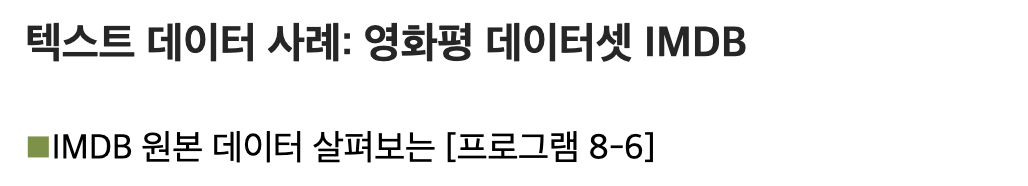

In [ ]:
import os
# 운영 체제와 관련된 파일 경로 처리 기능을 제공하는 os 모듈을 불러오기

# ==============================
# IMDB 영화 리뷰 원본 데이터 읽기
# ==============================

directory = './data/aclImdb/aclImdb/test'
# IMDB 테스트 데이터가 저장된 디렉토리 경로를 문자열로 정의하기

x = []  # 리뷰 텍스트를 저장할 리스트 초기화
y = []  # 리뷰 레이블(긍정/부정)을 저장할 리스트 초기화

for c in ['neg', 'pos']:
    # 부정(neg), 긍정(pos) 폴더를 순회하며 각 폴더의 파일을 처리하기 위한 반복문 정의

    curr = os.path.join(directory, c)
    # 현재 반복 중인 폴더('neg' 또는 'pos')의 전체 경로를 생성하기

    for fname in os.listdir(curr):
        # 해당 폴더 내의 모든 파일 이름을 순회하기 위한 반복문 정의

        if fname[-4:] == '.txt':
            # 파일 확장자가 '.txt'인 경우에만 처리하기 위한 조건문 정의

            f = open(os.path.join(curr, fname), encoding='utf8')
            # 현재 텍스트 파일을 UTF-8 인코딩으로 열기

            x.append(f.read())
            # 읽어들인 텍스트 파일 내용을 x 리스트에 추가하기

            y.append(c)
            # 현재 폴더명이 곧 레이블이므로 'neg' 또는 'pos'를 y 리스트에 추가하기

print("첫 번째 댓글:", x[0])
# x 리스트의 첫 번째 리뷰(댓글) 내용을 출력하기

print("첫 번째 평가:", y[0])
# y 리스트의 첫 번째 레이블(긍정/부정) 값을 출력하기

print("마지막 댓글:", x[-1])
# x 리스트의 마지막 리뷰(댓글) 내용을 출력하기

print("마지막 평가:", y[-1])
# y 리스트의 마지막 레이블(긍정/부정) 값을 출력하기


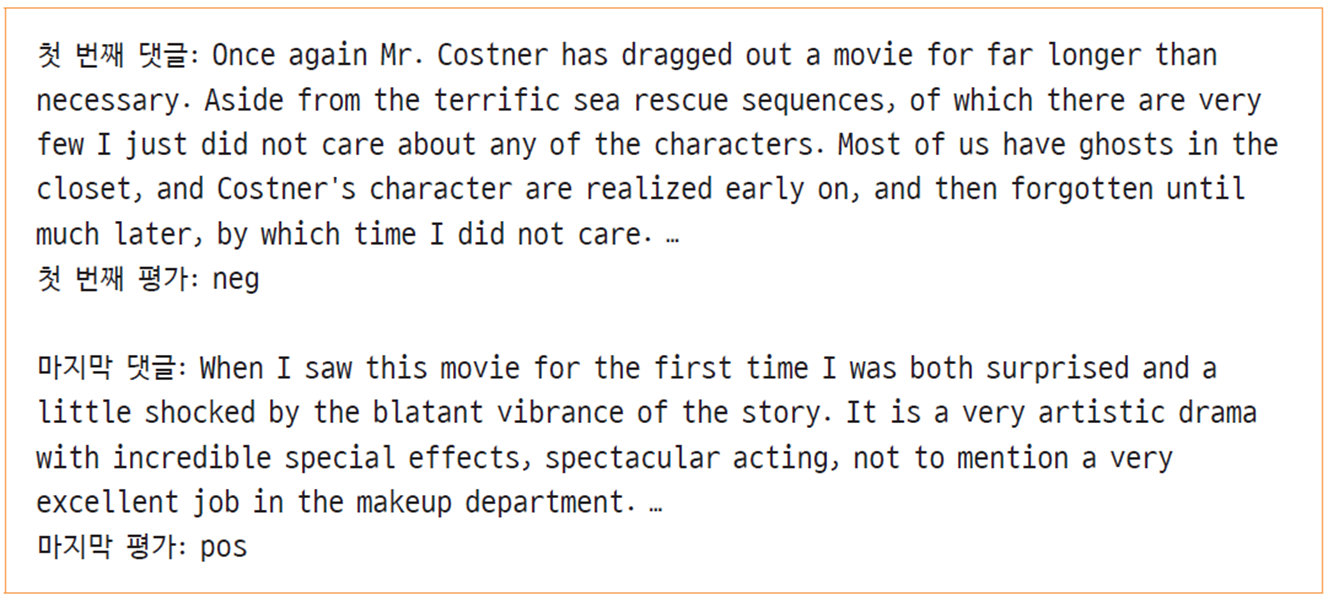

---

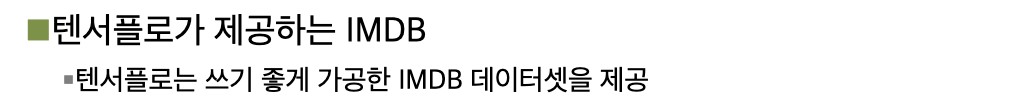

In [ ]:
# ------------------------------------------------------------
# [전체 개요: Overview]
# 본 코드는 Keras에서 제공하는 IMDB 영화 리뷰 데이터셋을 불러온 뒤,
# 각 리뷰를 구성하는 정수 인덱스 시퀀스를 확인하고, 해당 인덱스가 어떤 단어에 해당하는지를 추출하는 과정으로 구성됨.
# 사전 단어 수 제한, 인덱스 시퀀스 출력, 인덱스 → 단어 사전 구성, 일부 단어 출력 과정을 포함함.
# ------------------------------------------------------------

# ------------------------------------------------------------
# [처리 흐름: Step-by-step Flow]
# 1단계: 필요한 라이브러리 불러오기
# 2단계: 사전 크기 및 샘플 길이 설정
# 3단계: IMDB 데이터셋 로딩 및 시퀀스 확인
# 4단계: 단어 ↔ 인덱스 변환용 딕셔너리 구성 및 출력
# ------------------------------------------------------------

from tensorflow.keras.datasets import imdb
# → Keras에서 제공하는 IMDB 영화 리뷰 데이터셋 모듈을 불러오기

from tensorflow.keras.models import Sequential
# → 순차적으로 레이어를 쌓을 수 있는 Keras의 Sequential 모델 클래스 불러오기

from tensorflow.keras.layers import Dense, Flatten, Embedding
# → 완전연결(Dense), 평탄화(Flatten), 임베딩(Embedding) 레이어 클래스 불러오기

from tensorflow.keras import preprocessing
# → 시퀀스 데이터 전처리 기능을 제공하는 preprocessing 모듈 불러오기

dic_siz = 10000
# → 사용할 단어 사전의 최대 크기를 10,000개로 설정하기
# → IMDB 데이터셋에서 가장 자주 등장하는 10,000개의 단어만 사용할 것임

sample_siz = 512
# → 각 샘플마다 최대 단어 수를 512개로 제한하여
# → 시퀀스를 고정 길이로 처리하기 위한 변수 정의

# ==============================
# 1단계: IMDB 데이터셋 로딩 및 구조 확인
# ==============================

(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=dic_siz)
# → 사전 크기 제한을 적용하여 IMDB 데이터셋을 로딩하고,
# → 훈련용/테스트용 데이터로 분리하기
# → 각 리뷰는 단어의 인덱스 시퀀스로 구성되어 있으며,
# → y는 감정 레이블(0: 부정, 1: 긍정)임

print(x_train.shape, x_test.shape)
# → 훈련 데이터와 테스트 데이터의 크기를 출력하여 구조 확인하기

print(x_train[0])
# → 훈련용 첫 번째 리뷰 샘플을 출력하여 데이터 형태 확인하기
# → 결과는 단어 인덱스로 이루어진 정수 시퀀스임

# ==============================
# 2단계: 단어 ↔ 인덱스 변환 사전 정의 및 확인
# ==============================

word2id = imdb.get_word_index()
# → Keras가 제공하는 사전(단어 → 정수 인덱스)을 가져오기
# → 리뷰를 구성하는 단어가 어떤 인덱스로 매핑되어 있는지 확인 가능함

id2word = {id: word for word, id in word2id.items()}
# → 기존 딕셔너리를 뒤집어서 정수 인덱스를 단어로 변환하는 딕셔너리를 생성하기
# → 인덱스 값을 통해 원래 단어를 찾아볼 수 있도록 구성함

for i in range(1, 21):
    print(id2word[i], end='/')
# → 인덱스 1번부터 20번까지에 해당하는 단어를 출력하여 사전 구성 예시를 확인하기
# → 각 단어 사이에는 '/' 구분자를 삽입하여 출력함


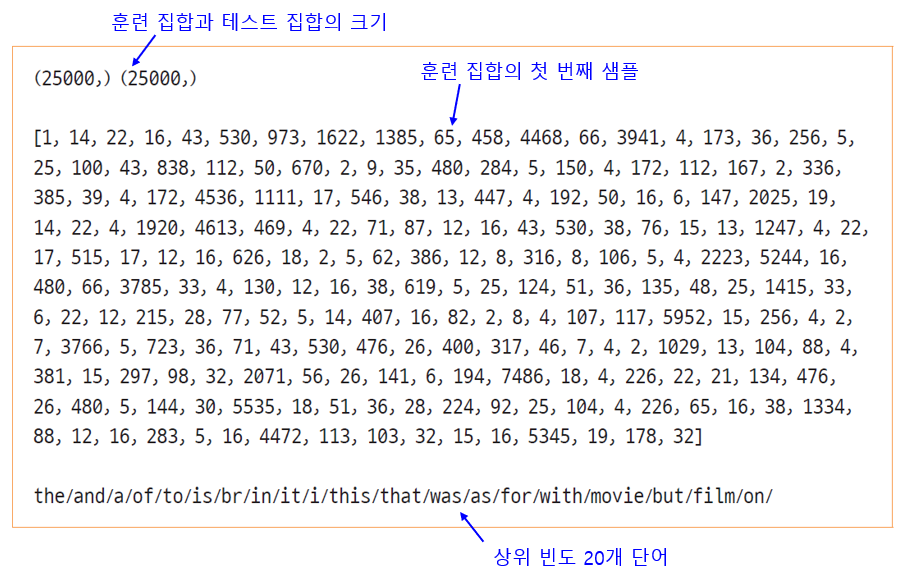

---

In [ ]:
# ------------------------------------------------------------
# [전체 개요: Overview]
# 본 코드는 Keras에서 제공하는 영화 리뷰 감성 분석용 IMDB 데이터셋을 불러와,
# 각 리뷰를 구성하는 정수 인덱스 시퀀스를 사람이 읽을 수 있는 원래 단어로 디코딩하는 예제임.
# 사전 단어 수 제한, 특수 토큰 처리, 인덱스 ↔ 단어 변환 사전 구성 과정을 포함함.
# ------------------------------------------------------------

# ------------------------------------------------------------
# [처리 흐름: Step-by-step Flow]
# 1단계: 필요한 모듈 임포트 및 사전 크기 설정
# 2단계: IMDB 데이터셋 로딩 및 숫자 시퀀스 확인
# 3단계: 단어 인덱스 딕셔너리 및 특수 토큰 처리
# 4단계: 첫 번째 리뷰를 사람이 읽을 수 있도록 디코딩
# ------------------------------------------------------------

from tensorflow.keras.datasets import imdb
# → Keras에서 제공하는 영화 리뷰 감정 분석용 IMDB 데이터셋 모듈을 불러오기

from tensorflow.keras.models import Sequential
# → 순차적으로 레이어를 구성할 수 있는 딥러닝 모델 클래스 불러오기

from tensorflow.keras.layers import Dense, Flatten, Embedding
# → 완전연결(Dense), 평탄화(Flatten), 임베딩(Embedding) 레이어 클래스 불러오기

from tensorflow.keras import preprocessing
# → 시퀀스 전처리 기능을 제공하는 preprocessing 모듈 불러오기

dic_siz = 10000
# → 사용할 단어 사전의 크기를 10,000개로 제한하여 가장 자주 쓰이는 단어만 추출하기

sample_siz = 512
# → 각 리뷰를 동일한 길이인 512개의 단어로 제한하기 위한 설정값 정의

# ==============================
# 1단계: IMDB 데이터셋 로딩
# ==============================

(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=dic_siz)
# → 가장 자주 등장한 단어 10,000개만 사용하여 IMDB 데이터셋을 불러오고
#    훈련용/테스트용 데이터로 나누기 (각 리뷰는 정수 인덱스로 구성됨)

print(x_train.shape, x_test.shape)
# → 훈련 데이터와 테스트 데이터의 샘플 수를 출력하여 데이터 구조를 확인하기

print("첫 번째 리뷰(숫자 시퀀스):", x_train[0][:20])
# → 첫 번째 리뷰의 정수 시퀀스를 앞에서 20개만 잘라 출력하여 데이터 형태를 확인하기

# ==============================
# 2단계: 단어 인덱스 딕셔너리 정의
# ==============================

word2id = imdb.get_word_index()
# → 원래 단어를 정수로 매핑하는 딕셔너리를 불러오기 (단어 → 인덱스)

index_from = 3
# → Keras가 0~2번 인덱스를 특수 토큰(PAD, START, OOV)으로 예약하므로
#    실제 단어 인덱스는 3부터 시작하도록 설정하기

# ==============================
# 3단계: 숫자 인덱스 → 단어 변환 딕셔너리 정의
# ==============================

id2word = {i + index_from: word for word, i in word2id.items()}
# → 단어 인덱스를 단어로 바꾸기 위해 word2id 딕셔너리를 뒤집고
#    각 인덱스에 3을 더하여 정수 → 단어 딕셔너리를 생성하기

id2word[0] = "[PAD]"
# → 0번 인덱스를 패딩(Padding)을 의미하는 특수 토큰으로 지정하기

id2word[1] = "[START]"
# → 1번 인덱스를 문장의 시작(Start)을 의미하는 특수 토큰으로 지정하기

id2word[2] = "[OOV]"
# → 2번 인덱스를 사전에 없는 단어(Out Of Vocabulary)를 나타내는 특수 토큰으로 지정하기

# ==============================
# 4단계: 첫 번째 리뷰 디코딩
# ==============================

decoded_review = " ".join(id2word.get(i, "?") for i in x_train[0][:20])
# → 첫 번째 리뷰의 정수 인덱스를 하나씩 순회하며
#    해당 인덱스에 매핑된 단어를 찾아 공백으로 연결하여 원래 문장으로 복원하기
#    딕셔너리에 없는 경우에는 "?" 기호로 대체하기

print("디코딩된 리뷰:", decoded_review)
# → 사람이 읽을 수 있는 형태로 복원된 문장을 출력하기


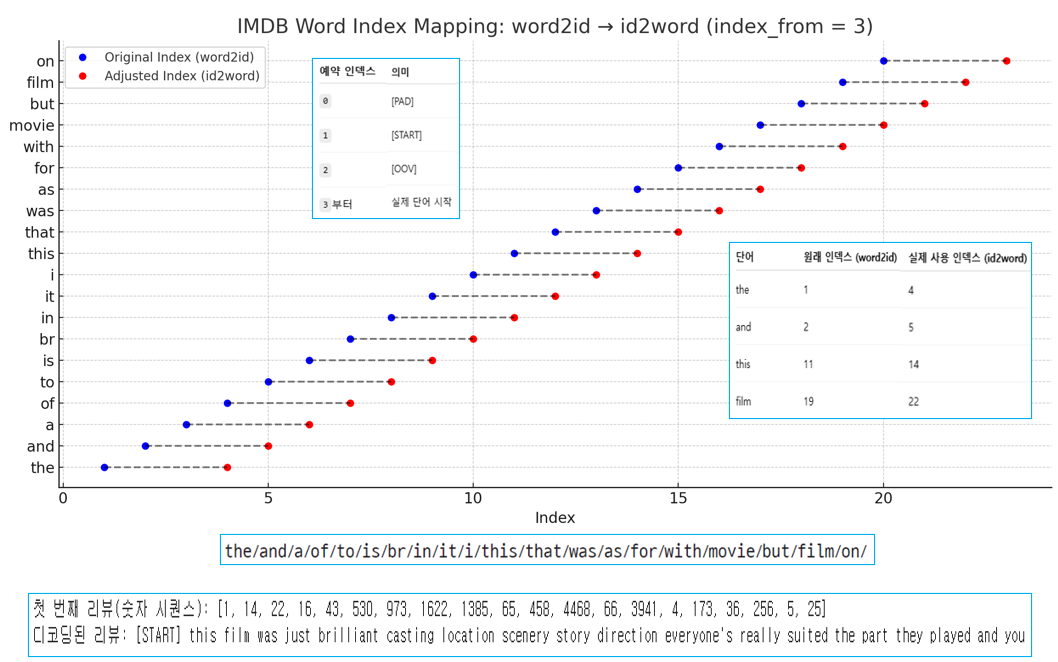

---

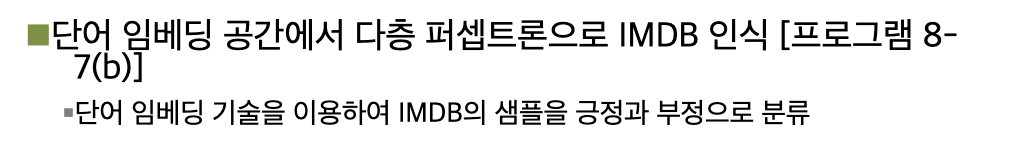

In [ ]:
# ------------------------------------------------------------
# [전체 개요: Overview]
# 본 코드는 IMDB 영화 리뷰 데이터를 활용하여 감정 분류(binary sentiment classification)를 수행하는 예제임.
# 텍스트는 정수 시퀀스로 표현되며, 이를 고정된 길이로 패딩한 후 임베딩 레이어를 통해 밀집 벡터로 변환함.
# 이후 Flatten, Dense 레이어를 통과시켜 긍정/부정을 분류하는 신경망 모델을 학습하고,
# 학습 곡선을 시각화하여 학습 성능을 분석함.
# ------------------------------------------------------------

# ------------------------------------------------------------
# [처리 흐름: Step-by-step Flow]
# 1단계: 임베딩 공간 차원 설정
# 2단계: 시퀀스 길이 고정 (pad_sequences)
# 3단계: 임베딩 기반 분류 모델 구성 및 학습 수행
# 4단계: 모델 구조 출력 및 성능 평가
# 5단계: 학습 정확도 시각화 (학습 곡선 플롯)
# ------------------------------------------------------------

embed_space_dim = 16
# 임베딩 공간의 차원을 16으로 설정하여 각 단어를 16차원 밀집 벡터로 표현함

x_train = preprocessing.sequence.pad_sequences(x_train, maxlen=sample_siz)
# 훈련용 리뷰 시퀀스를 고정된 길이(512개 단어)로 패딩하여 일관된 입력 형태로 정규화함

x_test = preprocessing.sequence.pad_sequences(x_test, maxlen=sample_siz)
# 테스트용 리뷰 시퀀스도 동일하게 패딩 처리함

# ==============================
# 3단계: 임베딩 기반 분류 모델 구성 및 학습 수행
# ==============================
embed = Sequential()
# 순차적으로 레이어를 쌓는 신경망 모델 인스턴스를 생성함

embed.add(Embedding(input_dim=dic_siz, output_dim=embed_space_dim, input_length=sample_siz))
# 단어 인덱스를 임베딩 벡터로 변환하는 Embedding 레이어를 추가함
# 입력 크기는 사전 크기(10,000), 출력은 16차원 벡터, 입력 시퀀스 길이는 512로 지정함

embed.add(Flatten())
# 임베딩 결과(512x16)를 일렬로 평탄화하여 Dense 레이어에 전달 가능하도록 변환함

embed.add(Dense(32, activation='relu'))
# 은닉층으로 32개의 뉴런을 가지며 ReLU 활성화 함수를 사용하는 완전연결 레이어를 추가함

embed.add(Dense(1, activation='sigmoid'))
# 출력층으로 이진 분류를 위한 sigmoid 활성화 함수를 사용하는 단일 뉴런 레이어를 추가함

embed.compile(loss='binary_crossentropy', optimizer='Adam', metrics=['accuracy'])
# 이진 분류 문제이므로 손실 함수는 binary_crossentropy, 최적화 방법은 Adam으로 설정함
# 정확도를 성능 지표로 사용함

hist = embed.fit(x_train, y_train, epochs=20, batch_size=64, validation_data=(x_test, y_test), verbose=2)
# 모델 학습을 20회 반복하며, 한 번에 64개의 샘플을 사용하여 배치 학습을 수행함
# 검증 데이터셋을 지정하여 매 epoch마다 검증 정확도를 확인함

embed.summary()
# 모델의 레이어 구성, 파라미터 수 등을 요약 출력함

# ==============================
# 4단계: 모델 평가 및 성능 확인
# ==============================
res = embed.evaluate(x_test, y_test, verbose=0)
# 테스트셋을 이용하여 최종 모델의 손실과 정확도를 평가함

print("정확률은", res[1] * 100)
# 평가 결과 중 정확도를 백분율로 변환하여 출력함

# ==============================
# 5단계: 학습 정확도 시각화
# ==============================
import matplotlib.pyplot as plt
# 시각화를 위한 matplotlib 라이브러리 임포트함

plt.plot(hist.history['accuracy'])
# 학습 데이터에 대한 epoch별 정확도 변화를 선 그래프로 표시함

plt.plot(hist.history['val_accuracy'])
# 검증 데이터에 대한 epoch별 정확도 변화를 함께 표시함

plt.title('Model accuracy')
# 그래프 제목 설정함

plt.ylabel('Accuracy')
# y축 라벨을 정확도로 설정함

plt.xlabel('Epoch')
# x축 라벨을 epoch(반복 횟수)로 설정함

plt.legend(['Train', 'Validation'], loc='best')
# 학습/검증 정확도에 대한 범례를 설정함

plt.grid()
# 그래프에 격자를 추가하여 가독성을 높임

plt.show()
# 정확도 변화 그래프를 화면에 출력함

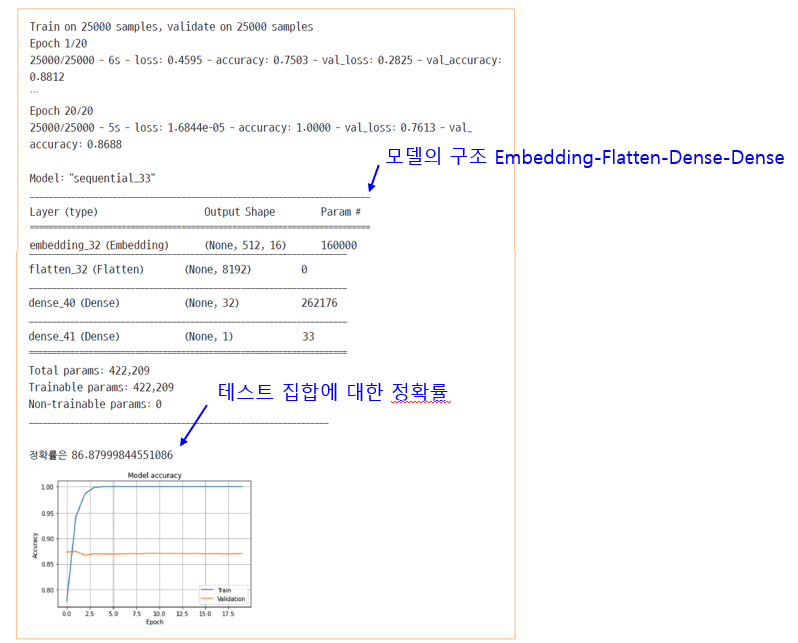

---

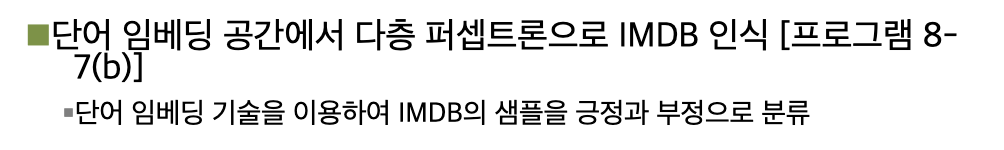

In [ ]:
# ------------------------------------------------------------
# [전체 개요: Overview]
# 본 코드는 Keras에서 제공하는 IMDB 영화 리뷰 데이터셋을 불러온 뒤,
# 정수 인덱스 시퀀스를 원래 단어로 변환하여 디코딩하는 과정과 함께,
# 임베딩층을 포함한 신경망 모델을 구성하여 감정 분류를 학습하고 정확도를 평가하는 전 과정을 포함함.
# 시퀀스 패딩, 임베딩 공간 구성, 모델 설계 및 평가, 학습 곡선 시각화를 포함함.
# ------------------------------------------------------------

# ------------------------------------------------------------
# [처리 흐름: Step-by-step Flow]
# 1단계: 필요한 라이브러리 불러오기
# 2단계: 사전 크기 및 샘플 길이 설정
# 3단계: IMDB 데이터셋 로딩 및 시퀀스 확인
# 4단계: 단어 ↔ 인덱스 변환용 딕셔너리 구성 및 출력
# 5단계: 시퀀스 패딩 처리 및 모델 구성
# 6단계: 모델 학습 및 평가
# 7단계: 학습 정확도 시각화
# ------------------------------------------------------------

from tensorflow.keras.datasets import imdb
# → Keras에서 제공하는 IMDB 영화 리뷰 데이터셋 모듈을 불러오기

from tensorflow.keras.models import Sequential
# → 순차적으로 레이어를 쌓을 수 있는 Keras의 Sequential 모델 클래스 불러오기

from tensorflow.keras.layers import Dense, Flatten, Embedding
# → 완전연결(Dense), 평탄화(Flatten), 임베딩(Embedding) 레이어 클래스 불러오기

from tensorflow.keras import preprocessing
# → 시퀀스 데이터 전처리 기능을 제공하는 preprocessing 모듈 불러오기

import matplotlib.pyplot as plt
# → 학습 곡선을 시각화하기 위한 matplotlib의 pyplot 모듈 불러오기

dic_siz = 10000
# → 사용할 단어 사전의 최대 크기를 10,000개로 설정하기
# → IMDB 데이터셋에서 가장 자주 등장하는 10,000개의 단어만 사용할 것임

sample_siz = 512
# → 각 샘플마다 최대 단어 수를 512개로 제한하여
# → 시퀀스를 고정 길이로 처리하기 위한 변수 정의

# ==============================
# 1단계: IMDB 데이터셋 로딩 및 구조 확인
# ==============================

(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=dic_siz)
# → 사전 크기 제한을 적용하여 IMDB 데이터셋을 로딩하고,
# → 훈련용/테스트용 데이터로 분리하기
# → 각 리뷰는 단어의 인덱스 시퀀스로 구성되어 있으며,
# → y는 감정 레이블(0: 부정, 1: 긍정)임

print(x_train.shape, x_test.shape)
# → 훈련 데이터와 테스트 데이터의 크기를 출력하여 구조 확인하기

print(x_train[0])
# → 훈련용 첫 번째 리뷰 샘플을 출력하여 데이터 형태 확인하기
# → 결과는 단어 인덱스로 이루어진 정수 시퀀스임

# ==============================
# 2단계: 단어 ↔ 인덱스 변환 사전 정의 및 확인
# ==============================

word2id = imdb.get_word_index()
# → Keras가 제공하는 사전(단어 → 정수 인덱스)을 가져오기
# → 리뷰를 구성하는 단어가 어떤 인덱스로 매핑되어 있는지 확인 가능함

id2word = {id: word for word, id in word2id.items()}
# → 기존 딕셔너리를 뒤집어서 정수 인덱스를 단어로 변환하는 딕셔너리를 생성하기
# → 인덱스 값을 통해 원래 단어를 찾아볼 수 있도록 구성함

for i in range(1, 21):
    print(id2word[i], end='/')
# → 인덱스 1번부터 20번까지에 해당하는 단어를 출력하여 사전 구성 예시를 확인하기
# → 각 단어 사이에는 '/' 구분자를 삽입하여 출력함

# ==============================
# 3단계: 시퀀스 패딩 처리
# ==============================

x_train = preprocessing.sequence.pad_sequences(x_train, maxlen=sample_siz)
# → 훈련용 데이터의 시퀀스를 sample_siz(512) 길이에 맞게 패딩 처리하여 고정 길이 배열로 변환하기

x_test = preprocessing.sequence.pad_sequences(x_test, maxlen=sample_siz)
# → 테스트용 데이터의 시퀀스를 동일하게 패딩 처리하여 고정 길이 배열로 변환하기

# ==============================
# 4단계: 신경망 모델 설계 및 학습
# ==============================

embed_space_dim = 16
# → 각 단어를 16차원 벡터 공간에 임베딩할 수 있도록 설정하기

embed = Sequential()
# → 순차적으로 레이어를 구성하기 위한 모델 객체 생성하기

embed.add(Embedding(input_dim=dic_siz, output_dim=embed_space_dim, input_length=sample_siz))
# → 단어 인덱스를 밀집 벡터로 변환하는 임베딩 레이어 추가하기
# → 단어 사전 크기 10000, 임베딩 차원 16, 입력 시퀀스 길이 512 설정하기

embed.add(Flatten())
# → 2D 임베딩 출력을 1D 벡터로 변환하여 완전연결층에 전달하기 위한 평탄화 레이어 추가하기

embed.add(Dense(32, activation='relu'))
# → 은닉 유닛 32개를 가지며 ReLU 활성화를 사용하는 완전연결 레이어 추가하기

embed.add(Dense(1, activation='sigmoid'))
# → 출력층: 이진 분류를 위한 시그모이드 활성화 함수 사용하여 확률 출력하기

embed.compile(loss='binary_crossentropy', optimizer='Adam', metrics=['accuracy'])
# → 손실 함수는 이진 크로스엔트로피, 최적화 방법은 Adam, 평가 지표는 정확도로 설정하여 컴파일하기

hist = embed.fit(x_train, y_train, epochs=20, batch_size=64, validation_data=(x_test, y_test), verbose=2)
# → 모델 학습 수행 (20 에폭, 배치 크기 64, 검증용 데이터 포함, 로그 출력)

embed.summary()
# → 모델의 전체 구조 요약 출력하기

# ==============================
# 5단계: 모델 평가 및 예측 정확도 출력
# ==============================

res = embed.evaluate(x_test, y_test, verbose=0)
# → 테스트 데이터를 이용하여 최종 모델 성능 평가 수행하기

print("정확률은", res[1] * 100)
# → 평가된 정확도를 백분율로 환산하여 출력하기

# ==============================
# 6단계: 학습 정확도 시각화
# ==============================

plt.plot(hist.history['accuracy'])
# → 학습용 데이터에 대한 정확도 변화 시각화

plt.plot(hist.history['val_accuracy'])
# → 검증용 데이터에 대한 정확도 변화 시각화

plt.title('Model accuracy')
# → 그래프 제목 설정

plt.ylabel('Accuracy')
# → y축 라벨 설정

plt.xlabel('Epoch')
# → x축 라벨 설정

plt.legend(['Train', 'Validation'], loc='best')
# → 그래프 범례 설정

plt.grid()
# → 격자 표시 활성화

plt.show()
# → 정확도 학습 곡선 출력


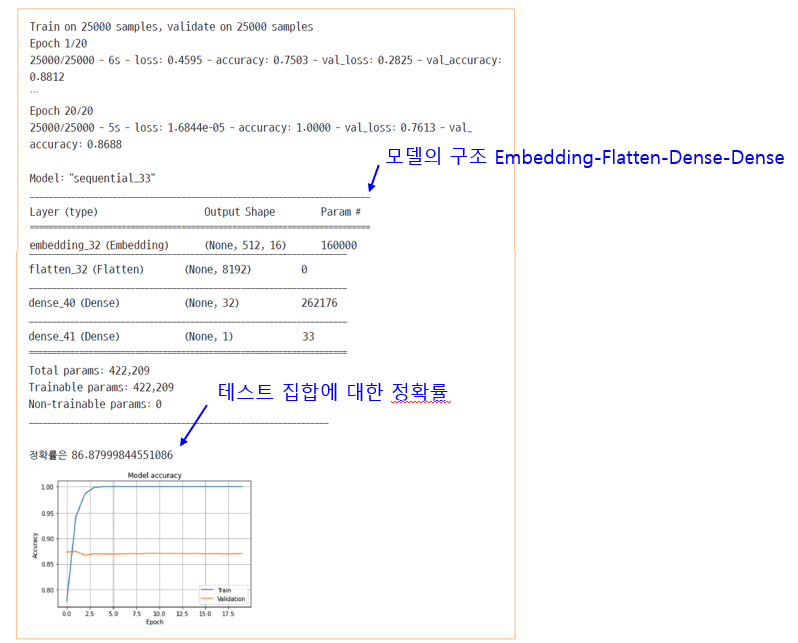

---

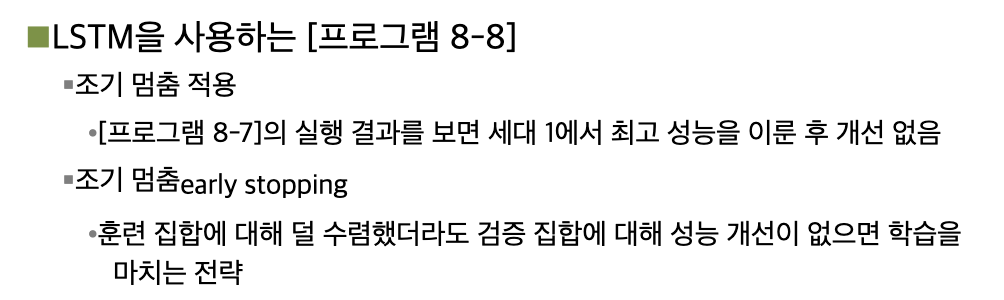

In [ ]:
# ------------------------------------------------------------
# [전체 개요: Overview]
# 본 코드는 Keras의 IMDB 영화 리뷰 데이터셋을 기반으로,
# 리뷰 시퀀스를 정수 인덱스로 구성하여 전처리한 후,
# 임베딩층과 LSTM(Long Short-Term Memory) 층을 포함한 감정 분류 모델을 설계하고 학습함.
# 얼리 스토핑 콜백을 사용해 과적합을 방지하며, 최종적으로 모델을 평가하고 학습 곡선을 시각화함.
# ------------------------------------------------------------

# ------------------------------------------------------------
# [처리 흐름: Step-by-step Flow]
# 1단계: 필요한 라이브러리 불러오기
# 2단계: 사전 크기 및 샘플 길이 설정
# 3단계: IMDB 데이터셋 로딩 및 시퀀스 확인
# 4단계: 시퀀스 패딩 처리
# 5단계: LSTM 기반 신경망 모델 구성 및 학습
# 6단계: 모델 평가 및 정확도 출력
# 7단계: 학습 정확도 시각화
# ------------------------------------------------------------

from tensorflow.keras.datasets import imdb
# → Keras에서 제공하는 IMDB 영화 리뷰 데이터셋 모듈을 불러오기

from tensorflow.keras.models import Sequential
# → 순차적으로 레이어를 구성할 수 있는 Keras의 Sequential 모델 클래스 불러오기

from tensorflow.keras.layers import Dense, LSTM, Embedding
# → 완전연결(Dense), 순환신경망 LSTM, 임베딩(Embedding) 레이어 클래스 불러오기

from tensorflow.keras import preprocessing
# → 시퀀스 데이터 전처리 기능을 제공하는 preprocessing 모듈 불러오기

from tensorflow.keras.callbacks import EarlyStopping
# → 조기 종료 콜백 함수를 통해 과적합을 방지하기 위한 콜백 클래스 불러오기

import matplotlib.pyplot as plt
# → 학습 곡선을 시각화하기 위한 matplotlib의 pyplot 모듈 불러오기

# ==============================
# 1단계: 사전 크기 및 샘플 길이 설정
# ==============================

dic_siz = 10000
# → 사용할 단어 사전의 최대 크기를 10,000개로 설정하기

sample_siz = 512
# → 각 리뷰를 512단어로 고정 길이 설정하여 시퀀스를 통일하기 위한 변수 정의

# ==============================
# 2단계: IMDB 데이터셋 로딩
# ==============================

(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=dic_siz)
# → 가장 자주 등장한 단어 10,000개만 사용하여 IMDB 데이터셋을 불러오고 훈련/테스트 데이터로 분리하기

# ==============================
# 3단계: 시퀀스 패딩 처리
# ==============================

x_train = preprocessing.sequence.pad_sequences(x_train, maxlen=sample_siz)
# → 훈련용 리뷰 시퀀스를 512 단어 길이로 패딩하여 고정 길이 배열로 변환하기

x_test = preprocessing.sequence.pad_sequences(x_test, maxlen=sample_siz)
# → 테스트용 리뷰 시퀀스도 동일하게 패딩 처리하여 입력 크기를 통일하기

# ==============================
# 4단계: 조기 종료 콜백 설정
# ==============================

early = EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True)
# → 검증 정확도를 기준으로 5회 연속 개선이 없으면 학습을 중단하고 가장 좋은 가중치를 복원하는 콜백 설정하기

# ==============================
# 5단계: LSTM 기반 신경망 모델 구성 및 학습
# ==============================

embed_space_dim = 16
# → 각 단어를 16차원 벡터로 임베딩하기 위한 차원 수 설정하기

embed = Sequential()
# → 모델 객체를 생성하여 레이어를 순차적으로 쌓을 수 있도록 초기화하기

embed.add(Embedding(input_dim=dic_siz, output_dim=embed_space_dim, input_length=sample_siz))
# → 단어 인덱스를 밀집 벡터로 임베딩하는 레이어 추가하기

embed.add(LSTM(units=32))
# → 순환 신경망 LSTM 레이어를 추가하여 시퀀스 정보를 학습하도록 구성하기 (유닛 수 32개)

embed.add(Dense(1, activation='sigmoid'))
# → 출력층으로 1개의 뉴런과 시그모이드 함수를 사용하여 이진 감정 분류 확률 출력하기

embed.compile(loss='binary_crossentropy', optimizer='Adam', metrics=['accuracy'])
# → 손실 함수로 이진 크로스엔트로피, Adam 최적화, 정확도를 평가 지표로 설정하여 모델 컴파일하기

hist = embed.fit(
    x_train, y_train,
    epochs=20,
    batch_size=64,
    validation_split=0.2,
    verbose=2,
    callbacks=[early]
)
# → 모델을 훈련 데이터로 학습시키며 조기 종료 콜백을 포함하여 과적합을 방지함
# → 에폭 수는 최대 20, 검증 데이터는 훈련 데이터의 20%로 자동 분할하여 사용함

# ==============================
# 6단계: 모델 평가 및 정확도 출력
# ==============================

res = embed.evaluate(x_test, y_test, verbose=0)
# → 테스트 데이터를 기반으로 학습된 모델 성능 평가하기

print("정확률은", res[1] * 100)
# → 정확도를 백분율로 환산하여 출력하기

# ==============================
# 7단계: 학습 정확도 시각화
# ==============================

plt.plot(hist.history['accuracy'])
# → 학습용 데이터에 대한 정확도 변화 곡선 시각화

plt.plot(hist.history['val_accuracy'])
# → 검증용 데이터에 대한 정확도 변화 곡선 시각화

plt.title('Model accuracy')
# → 그래프 제목 설정하기

plt.ylabel('Accuracy')
# → y축 라벨 설정하기

plt.xlabel('Epoch')
# → x축 라벨 설정하기

plt.legend(['Train', 'Validation'], loc='best')
# → 그래프 범례 설정하기

plt.grid()
# → 격자 표시 활성화하기

plt.show()
# → 정확도 학습 곡선 출력하기


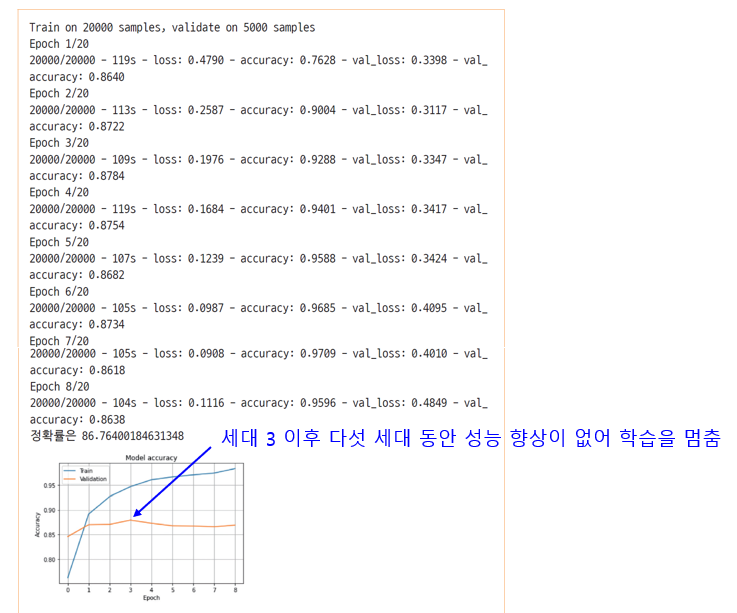

---

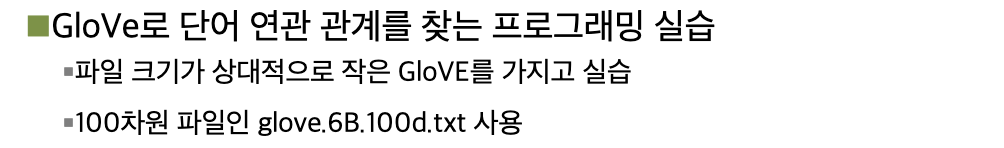

In [ ]:
# ------------------------------------------------------------
# [전체 개요: Overview]
# 본 코드는 GloVe(Global Vectors for Word Representation) 사전 훈련된 단어 임베딩을 로딩하고,
# 특정 단어와 가장 유사한 단어를 유클리드 거리 기준으로 찾아내며,
# 임베딩 벡터 간 연산을 통해 단어 유추(word analogy) 문제를 해결하는 예제를 포함함.
# ------------------------------------------------------------

# ------------------------------------------------------------
# [처리 흐름: Step-by-step Flow]
# 1단계: GloVe 파일 경로 지정 및 첫 줄 출력
# 2단계: GloVe 임베딩 파일을 읽어 딕셔너리로 저장
# 3단계: 유클리드 거리 기반으로 유사한 단어를 찾는 함수 정의
# 4단계: 단어 유사도 및 단어 유추 결과 출력
# ------------------------------------------------------------

import os
# → 파일 경로 처리를 위한 표준 라이브러리 os 불러오기

import numpy as np
# → 수치 연산 및 배열 처리를 위한 NumPy 불러오기

from scipy.spatial import distance
# → 거리 계산을 위한 scipy.spatial.distance 모듈 불러오기

# ==============================
# 1단계: GloVe 파일 경로 지정 및 첫 줄 출력
# ==============================

fname = './glove.6B/glove.6B.100d.txt'
# → 100차원 GloVe 임베딩 파일 경로 지정하기

f = open(fname, encoding='utf8')
# → 해당 파일을 UTF-8 인코딩으로 열기

for line in f:
    print(type(line))
    # → 첫 줄의 데이터 타입 출력하기
    print(line)
    # → 첫 줄의 내용 전체 출력하기
    break
    # → 샘플 출력 후 루프 종료하기

# ==============================
# 2단계: GloVe 임베딩 파일을 읽어 딕셔너리로 저장
# ==============================

dictionary = {}
# → 단어를 key, 임베딩 벡터를 value로 저장할 딕셔너리 초기화하기

for line in f:
    li = line.split()
    # → 각 줄을 공백 기준으로 분리하여 리스트로 변환하기
    word = li[0]
    # → 리스트의 첫 번째 요소는 단어로 설정하기
    vector = np.asarray(li[1:], dtype='float32')
    # → 나머지 숫자들은 float32 타입의 벡터로 변환하기
    dictionary[word] = vector
    # → 단어와 벡터 쌍을 딕셔너리에 저장하기

# ==============================
# 3단계: 유클리드 거리 기반으로 유사한 단어를 찾는 함수 정의
# ==============================

def find_closest_words(vector):
    return sorted(dictionary.keys(), key=lambda w: distance.euclidean(dictionary[w], vector))
    # → 입력 벡터와 모든 단어 벡터 간 유클리드 거리를 계산하여 오름차순 정렬된 단어 리스트 반환하기

# ==============================
# 4단계: 단어 유사도 및 단어 유추 결과 출력
# ==============================

print(find_closest_words(dictionary['movie'])[:5])
# → 'movie'와 가장 가까운 상위 5개 단어 출력하기

print(find_closest_words(dictionary['school'])[:5])
# → 'school'과 가장 가까운 상위 5개 단어 출력하기

print(find_closest_words(dictionary['oak'])[:5])
# → 'oak'과 가장 가까운 상위 5개 단어 출력하기

print(find_closest_words(dictionary['seoul'] - dictionary['korea'] + dictionary['spain'])[:5])
# → "seoul" - "korea" + "spain" 벡터 연산을 통해 의미 유추 결과 상위 5개 출력하기

print(find_closest_words(dictionary['animal'] - dictionary['lion'] + dictionary['oak'])[:5])
# → "animal" - "lion" + "oak" 연산을 통한 유사 단어 추론 결과 출력하기

print(find_closest_words(dictionary['queen'] - dictionary['king'] + dictionary['actress'])[:5])
# → "queen" - "king" + "actress" 연산을 통한 유사 단어 추론 결과 출력하기


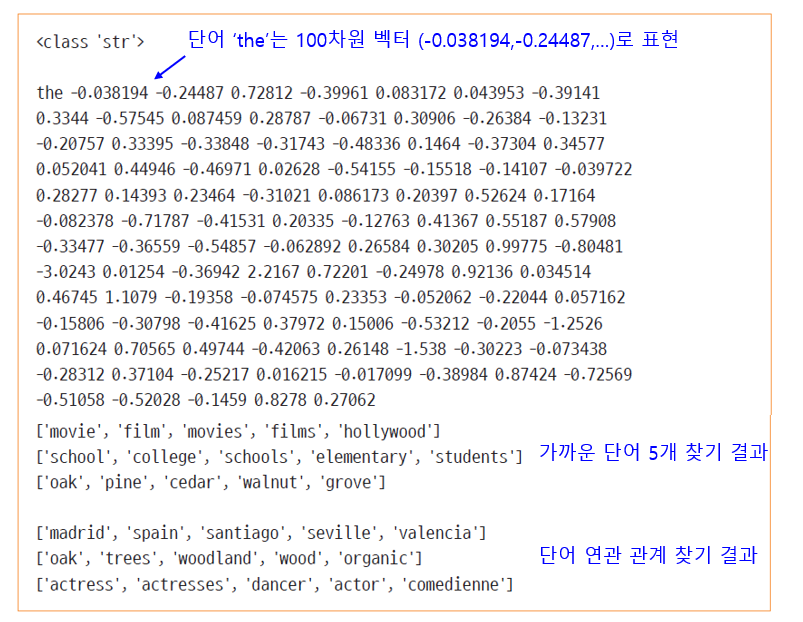

---

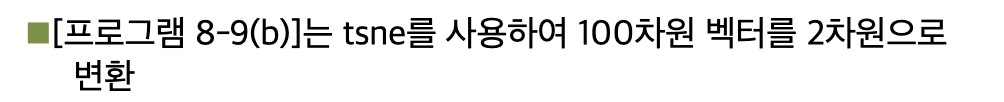

In [ ]:
# ------------------------------------------------------------
# [전체 개요: Overview]
# 본 코드는 GloVe(Global Vectors for Word Representation) 사전 훈련된 단어 임베딩을 로딩하고,
# 특정 단어와 가장 유사한 단어를 유클리드 거리 기준으로 찾아내며,
# 임베딩 벡터 간 연산을 통해 단어 유추(word analogy) 문제를 해결하는 예제를 포함함.
# 또한, 임베딩 벡터를 t-SNE를 이용해 2차원으로 축소하여 시각화함.
# ------------------------------------------------------------

# ------------------------------------------------------------
# [처리 흐름: Step-by-step Flow]
# 1단계: GloVe 파일 경로 지정 및 첫 줄 출력
# 2단계: GloVe 임베딩 파일을 읽어 딕셔너리로 저장
# 3단계: 유클리드 거리 기반으로 유사한 단어를 찾는 함수 정의
# 4단계: 단어 유사도 및 단어 유추 결과 출력
# 5단계: t-SNE 기반 시각화를 통한 단어 분포 확인
# ------------------------------------------------------------

import os
# → 파일 경로 처리를 위한 표준 라이브러리 os 불러오기

import numpy as np
# → 수치 연산 및 배열 처리를 위한 NumPy 불러오기

from scipy.spatial import distance
# → 거리 계산을 위한 scipy.spatial.distance 모듈 불러오기

from sklearn.manifold import TSNE
# → 고차원 데이터를 2차원으로 축소하기 위한 t-SNE 알고리즘 불러오기

import matplotlib.pyplot as plt
# → 시각화를 위한 matplotlib의 pyplot 모듈 불러오기

# ==============================
# 1단계: GloVe 파일 경로 지정 및 첫 줄 출력
# ==============================

fname = './glove.6B/glove.6B.100d.txt'
# → 100차원 GloVe 임베딩 파일 경로 지정하기

f = open(fname, encoding='utf8')
# → 해당 파일을 UTF-8 인코딩으로 열기

for line in f:
    print(type(line))
    # → 첫 줄의 데이터 타입 출력하기
    print(line)
    # → 첫 줄의 내용 전체 출력하기
    break
    # → 샘플 출력 후 루프 종료하기

# ==============================
# 2단계: GloVe 임베딩 파일을 읽어 딕셔너리로 저장
# ==============================

dictionary = {}
# → 단어를 key, 임베딩 벡터를 value로 저장할 딕셔너리 초기화하기

for line in f:
    li = line.split()
    # → 각 줄을 공백 기준으로 분리하여 리스트로 변환하기
    word = li[0]
    # → 리스트의 첫 번째 요소는 단어로 설정하기
    vector = np.asarray(li[1:], dtype='float32')
    # → 나머지 숫자들은 float32 타입의 벡터로 변환하기
    dictionary[word] = vector
    # → 단어와 벡터 쌍을 딕셔너리에 저장하기

# ==============================
# 3단계: 유클리드 거리 기반으로 유사한 단어를 찾는 함수 정의
# ==============================

def find_closest_words(vector):
    return sorted(dictionary.keys(), key=lambda w: distance.euclidean(dictionary[w], vector))
    # → 입력 벡터와 모든 단어 벡터 간 유클리드 거리를 계산하여 오름차순 정렬된 단어 리스트 반환하기

# ==============================
# 4단계: 단어 유사도 및 단어 유추 결과 출력
# ==============================

print(find_closest_words(dictionary['movie'])[:5])
# → 'movie'와 가장 가까운 상위 5개 단어 출력하기

print(find_closest_words(dictionary['school'])[:5])
# → 'school'과 가장 가까운 상위 5개 단어 출력하기

print(find_closest_words(dictionary['oak'])[:5])
# → 'oak'과 가장 가까운 상위 5개 단어 출력하기

print(find_closest_words(dictionary['seoul'] - dictionary['korea'] + dictionary['spain'])[:5])
# → "seoul" - "korea" + "spain" 벡터 연산을 통해 의미 유추 결과 상위 5개 출력하기

print(find_closest_words(dictionary['animal'] - dictionary['lion'] + dictionary['oak'])[:5])
# → "animal" - "lion" + "oak" 연산을 통한 유사 단어 추론 결과 출력하기

print(find_closest_words(dictionary['queen'] - dictionary['king'] + dictionary['actress'])[:5])
# → "queen" - "king" + "actress" 연산을 통한 유사 단어 추론 결과 출력하기

# ==============================
# 5단계: t-SNE 기반 시각화를 통한 단어 분포 확인
# ==============================

tsne = TSNE(n_components=2, random_state=0)
# → 임베딩 벡터를 2차원으로 축소하기 위한 t-SNE 모델 정의하기

words = list(dictionary.keys())
# → 단어 리스트를 추출하여 순서를 유지하기 위한 리스트 생성하기

vectors = [dictionary[word] for word in words]
# → 각 단어에 대응하는 임베딩 벡터를 리스트로 수집하기

p2 = tsne.fit_transform(vectors[:100])
# → 처음 100개 단어의 벡터를 대상으로 t-SNE로 2차원 축소 수행하기

plt.figure(figsize=(10, 7))
# → 출력 그래프의 크기를 설정하기
plt.scatter(p2[:, 0], p2[:, 1])
# → 축소된 2차원 좌표를 산점도로 표시하기

for label, x, y in zip(words[:100], p2[:, 0], p2[:, 1]):
    plt.annotate(label, xy=(x, y))
    # → 각 점 위에 단어 레이블을 시각적으로 표시하기

plt.title("t-SNE visualization of GloVe embeddings (Top 100 words)")
# → 그래프 제목 설정하기
plt.grid(True)
# → 그래프에 격자선 추가하기
plt.show()
# → 최종 시각화 결과 출력하기


In [ ]:
# 코랩에서 실행되는 코드

import numpy as np
# → 고차원 임베딩 벡터를 배열로 처리하기 위한 NumPy 패키지 불러오기

from sklearn.manifold import TSNE
# → t-SNE (t-Distributed Stochastic Neighbor Embedding) 차원 축소 기법을 위한 클래스 불러오기

import matplotlib.pyplot as plt
# → 데이터 시각화를 위한 matplotlib의 pyplot 모듈 불러오기

# ==============================
# 1단계: 사전에서 단어 벡터 추출
# ==============================

words = list(dictionary.keys())
# → 임베딩 사전의 키(단어)들을 리스트로 변환하여 순서를 보장하기

vectors = np.array([dictionary[word] for word in words])
# → 각 단어에 대한 임베딩 벡터들을 순서대로 추출하여 넘파이 배열로 변환하기

# ==============================
# 2단계: t-SNE를 이용한 차원 축소
# ==============================

tsne = TSNE(n_components=2, random_state=0, perplexity=30)
# → 100차원 벡터를 2차원으로 축소하기 위해 t-SNE 객체 생성하기
# → perplexity는 국지 구조의 균형을 조절하는 하이퍼파라미터로서 일반적으로 5~50 사이 값 사용

p2 = tsne.fit_transform(vectors[:100])
# → 임베딩 벡터 중 상위 100개 단어의 벡터를 대상으로 2차원으로 축소 수행하기

# ==============================
# 3단계: 시각화 수행
# ==============================

plt.figure(figsize=(12, 8))
# → 출력될 그래프의 크기를 12 x 8 인치로 설정하기

plt.scatter(p2[:, 0], p2[:, 1])
# → 2차원 축소된 벡터 좌표들을 산점도로 시각화하기

for label, x, y in zip(words[:100], p2[:, 0], p2[:, 1]):
    plt.annotate(label, xy=(x, y))
    # → 각 점 위에 해당하는 단어 레이블을 주석 형태로 시각화하여 위치 지정하기

plt.title("t-SNE Visualization of Word Embeddings")
# → 그래프 상단에 제목을 추가하여 시각화 목적 명시하기

plt.grid(True)
# → 배경에 격자선을 표시하여 해석 용이성 높이기

plt.show()
# → 그래프를 실제로 출력하여 시각화 완료하기


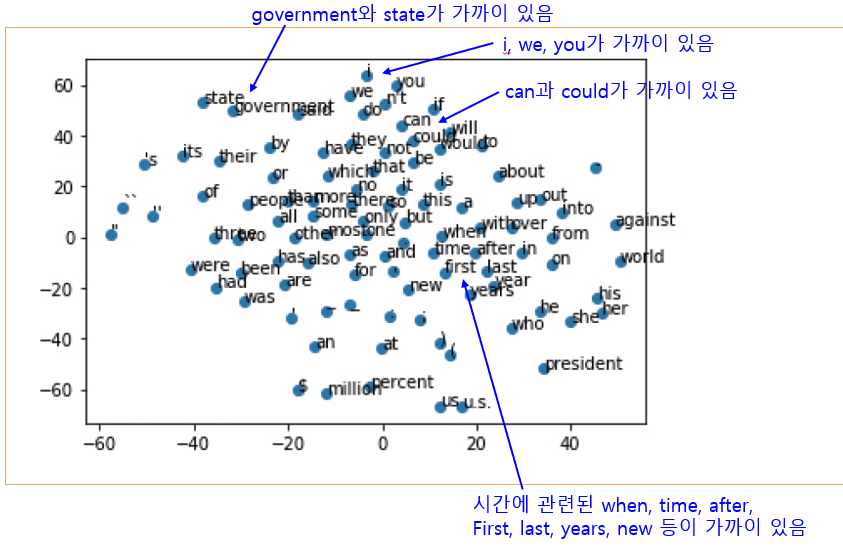